# Part 6: Figures and analysis — LSTM

## Introduction
This is the main analysis notebook for the LSTM results. It loads the per-fold, per-seed NeuralHydrology evaluation pickle files, aggregates them into NetCDF files per experiment, computes the modified NSE (expo=0.5) and hydrological signatures, and runs Wilcoxon signed-rank tests with Holm correction. LSTM performance is evaluated across five seeds and five spatial CV folds, with results averaged across seeds before statistical testing. All main figures and supplementary tables in the paper (LSTM section) are produced here.

Alongside the other notebooks, it covers all the analysis performed in: "Assessing the Impact of Geological Map Detail on Process-Based and Data-Driven Hydrological Models" by do Nascimento et al. (2026).

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

## Requirements

**From this repository (`../data/`):**

- `network_estreams_moselle_108_gauges.csv` — 108 Moselle study gauges with group assignments and static attributes (produced by Part-1a Moselle)
- `network_estreams_garonne_22_gauges.csv` — 22 Garonne study gauges with group assignments and static attributes (produced by Part-1b Garonne)
- `estreams_geology_garonne_regional_attributes.csv` — regional-scale lithological fractions for 22 Garonne catchments (produced by Part-0)

**LSTM run outputs** — produced by training NeuralHydrology with the config files from Part-2b LSTM (set `base_root` in the Configurations cell):

- `results/LSTM/0{3}_seed{28,33,44,55,77}/moselle_{glo,con,reg,nog,ran}_seed*_fold*/test/model_epoch*/test_results.p` — per-fold, per-seed LSTM evaluation results (pickle files)

**Produced by this notebook:**

- `../results/sim/sim_lstm/space-time/*.nc` — aggregated LSTM space-time simulations (per seed, averaged across seeds)
- `../results/sim/sim_lstm/time/*.nc` — aggregated LSTM time (training period) simulations
- `../results/sim/sim_lstm/space/*.nc` — aggregated LSTM space (leave-one-out) simulations
- `../results/supplementary_wilcoxon_results_LSTM.csv` — Wilcoxon signed-rank test results with Holm correction for all metrics
- `../results/TableS17_LSTM.csv` — full per-gauge performance summary for the SI

**Python packages:** `pandas`, `numpy`, `xarray`, `geopandas`, `matplotlib`, `seaborn`, `tqdm`, `scipy`, `pickle`, `pathlib`, `neuralhydrology` (for signatures)


## Import the modules

In [1]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import tqdm as tqdm
from utils.functions import find_max_unique_rows
from utils.functions import find_iterative_immediate_downstream
import geopandas as gpd

## Set the path to the data

In [2]:
# Path to where the EStreams dataset is stored
# Eawag
path_estreams = r'/Users/nascimth/Documents/data/EStreams'

## Mac
#path_estreams = r'/Users/thiagomedeirosdonascimento/Downloads/Python 2/Scripts/estreams_part_b/data/EStreams'

path_data = r"/Users/nascimth/Documents/data"

## Read the files

In [3]:
network_estreams_moselle_108_gauges = pd.read_csv('../data/network_estreams_moselle_108_gauges.csv', encoding='utf-8')
network_estreams_moselle_108_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_moselle_108_gauges.set_index("basin_id", inplace = True)
network_estreams_moselle_108_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,irri_1990,irri_2005,stations_num_p_mean,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_glob2,perm_medium_glob2,perm_low_glob2,group
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,0,5,Schoenfels,LU,LU_CONTACTFORM,Mamer,6.100795,49.723112,6.100795,49.723112,...,0.015,0.015,17.0,39.0,61.0,0.0,0.0,100.0,0.0,Group_1
LU000010,1,6,Hunnebuer,LU,LU_CONTACTFORM,Eisch,6.079524,49.729184,6.079524,49.729184,...,0.026,0.026,16.0,42.0,58.0,0.0,1.0,99.0,0.0,Group_1
LU000001,2,17,Bigonville,LU,LU_CONTACTFORM,Sure,5.801399,49.869821,5.801399,49.869821,...,0.000,0.000,9.0,1.0,0.0,99.0,100.0,0.0,0.0,Group_1
DERP2028,3,2674030900,Eisenschmitt,DE,DE_RP,Salm,6.718000,50.048000,6.718000,50.048000,...,0.000,0.000,10.0,80.0,7.0,13.0,79.0,20.0,1.0,Group_1
FR000183,4,A900105050,A9001050,FR,FR_EAUFRANCE,La Sarre à Laneuveville-lès-Lorquin,7.008689,48.654579,7.008689,48.654579,...,0.000,0.000,4.0,66.0,29.0,5.0,64.0,30.0,6.0,Group_1


In [4]:
network_estreams_garonne_22_gauges = pd.read_csv('../data/network_estreams_garonne_22_gauges.csv', encoding='utf-8')
network_estreams_garonne_22_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_garonne_22_gauges.set_index("basin_id", inplace = True)
network_estreams_garonne_22_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,perm_medium_cont2,perm_low_cont2,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,52.863,47.137,NaN,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,100.000,0.000,NaN,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,49.849,50.151,NaN,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,97.803,0.000,3.648649,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,94.518,5.483,NaN,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1


In [5]:
geology_regional = pd.read_csv("../data/estreams_geology_garonne_regional_attributes.csv", encoding='utf-8')

geology_regional.set_index("basin_id", inplace = True)

# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": [ "lit_fra_Alluvium",

             'lit_fra_Sand, gravel and pebbles'    
        ],
    
    "medium": ['lit_fra_Carbonate rocks', 
               'lit_fra_Limestones', 
               'lit_fra_Limestones, sandstones and gravels', 
               'lit_fra_Limestones, sandstones and marls', 
               'lit_fra_Molasses and clays',  
               'lit_fra_Sands and clays',
                'lit_fra_Sedimentary rocks',
               'lit_fra_Sediments mesosoics',
            'lit_fra_Schists, gneisses, granites', 
             ],
    
    "low": ['lit_fra_Impermeable', 
            'lit_fra_Inland water', 
            'lit_fra_Magmatic rocks', 
            'lit_fra_Massif', 
            'lit_fra_Plutonic rocks',
            'lit_fra_Shales',
            'lit_fra_Granitoids',

                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional[f'area_perm_{permeability_class}'] = geology_regional[columns].sum(axis=1)



# Drop unnecessary columns
geology_regional = geology_regional[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]


# Concatenation
network_estreams_garonne_22_gauges[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]

for basin_id in network_estreams_garonne_22_gauges.index.tolist():

    # Extract and divide by 100
    v1 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] / 100
    v2 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] / 100
    v3 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] = v1 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] = v2 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] = v3 * 100

network_estreams_garonne_22_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
FR004140,5,O163401001,La VixiÃ¨ge Ã Belpech,FR,FR_EAUFRANCE,La Vixiège à Belpech,1.749951,43.201718,1.749951,43.201718,...,0.000000,195.640,718.685,0.000000,0.822625,0.817920,Group_1,0.0,100.0,0.0
FR004149,6,O184402001,La LÃ¨ze Ã LÃ©zat-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Lézat-sur-Lèze,1.352878,43.280809,1.352878,43.280809,...,12.564601,178.485,775.260,0.016207,0.853714,0.893136,Group_1,0.0,94.0,6.0
FR004152,7,O187401001,La LÃ¨ze Ã Labarthe-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Labarthe-sur-Lèze,1.406594,43.451190,1.406594,43.451190,...,8.638464,161.330,740.220,0.011670,0.866051,0.889248,Group_1,5.0,91.0,4.0
FR001593,8,O222251001,O2222510,FR,FR_EAUFRANCE,L'Hers à Toulouse [Pont de Périole],1.480100,43.627770,1.480100,43.627770,...,9.651561,138.335,665.030,0.014513,0.820100,0.826636,Group_1,1.0,99.0,0.0


In [6]:
network_estreams_garonne_and_moselle = pd.concat([network_estreams_garonne_22_gauges, network_estreams_moselle_108_gauges])
network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,16.0,19.0,65.0
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,8.0,92.0,0.0
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,17.0,83.0,0.0


In [7]:
import numpy as np

network_estreams_garonne_and_moselle = network_estreams_garonne_and_moselle.copy()

rng = np.random.default_rng(seed=42)

# Step 1: draw random proportions
perms = rng.dirichlet(alpha=[1, 1, 1], size=len(network_estreams_garonne_and_moselle))

# Step 2: convert to percentages
perms = perms * 100.0

# Step 3: round to 1 decimal, fix residual
perms_rounded = np.floor(perms * 10) / 10  # floor to 1 decimal

residual = 100.0 - perms_rounded.sum(axis=1)

# Step 4: distribute residual (0.1 steps) safely
for i in range(len(network_estreams_garonne_and_moselle)):
    n_steps = int(round(residual[i] * 10))
    if n_steps > 0:
        idx = np.argsort(perms[i] - perms_rounded[i])[-n_steps:]
        perms_rounded[i, idx] += 0.1

network_estreams_garonne_and_moselle["perm_high_rand"] = perms_rounded[:, 0]
network_estreams_garonne_and_moselle["perm_medium_rand"] = perms_rounded[:, 1]
network_estreams_garonne_and_moselle["perm_low_rand"] = perms_rounded[:, 2]


In [9]:
network_estreams_garonne_and_moselle["lakes_depth_mean"] = network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.lakes_tot_area
network_estreams_garonne_and_moselle["lakes_depth_mean_norm"] = (network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.area_estreams)*1000
network_estreams_garonne_and_moselle["q_mean_yr"]= network_estreams_garonne_and_moselle.q_mean*365
network_estreams_garonne_and_moselle["p_mean_yr"]= network_estreams_garonne_and_moselle.p_mean*365

network_estreams_garonne_and_moselle["norm_ups_cap"]= network_estreams_garonne_and_moselle["lakes_depth_mean_norm"]/network_estreams_garonne_and_moselle["p_mean_yr"]

In [10]:
network_estreams_garonne_and_moselle["perm_high_glob2"] = network_estreams_garonne_and_moselle["perm_high_glob"]
network_estreams_garonne_and_moselle["perm_medium_glob2"] = network_estreams_garonne_and_moselle["perm_medium_glob"] + network_estreams_garonne_and_moselle["perm_low_glob"]
network_estreams_garonne_and_moselle["perm_low_glob2"] = network_estreams_garonne_and_moselle["perm_verylow_glob"]

network_estreams_garonne_and_moselle["perm_high_cont2"] = network_estreams_garonne_and_moselle["perm_high_cont"]
network_estreams_garonne_and_moselle["perm_medium_cont2"] = network_estreams_garonne_and_moselle["perm_medium_cont"] + network_estreams_garonne_and_moselle["perm_low_cont"]
network_estreams_garonne_and_moselle["perm_low_cont2"] = network_estreams_garonne_and_moselle["perm_verylow_cont"]

network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_rand,perm_medium_rand,perm_low_rand
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0,33.7,32.8,33.5
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0,15.4,4.7,79.9
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0,30.6,67.7,1.7
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0,47.4,3.2,49.4
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0,51.7,11.5,36.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,0.003874,NaN,NaN,Group_7,16.0,19.0,65.0,26.1,14.3,59.6
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,0.052949,NaN,NaN,Group_7,8.0,92.0,0.0,62.1,31.0,6.9
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,0.066980,NaN,NaN,Group_7,17.0,83.0,0.0,26.4,43.7,29.9


In [11]:
cols = ["perm_high_glob2", "perm_medium_glob2", "perm_low_glob2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_glob2,perm_medium_glob2,perm_low_glob2
basin_id,,,
FR004136,23.0,77.0,0.0
FR001547,13.0,87.0,0.0
FR004091,4.0,87.0,9.0
FR001592,11.0,89.0,0.0
FR001577,3.0,97.0,0.0
...,...,...,...
DERP2007,7.0,93.0,0.0
FR003271,0.0,100.0,0.0
FR003301,15.0,85.0,0.0


In [12]:
cols = ["perm_high_cont2", "perm_medium_cont2", "perm_low_cont2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_cont2,perm_medium_cont2,perm_low_cont2
basin_id,,,
FR004136,0.0,53.0,47.0
FR001547,0.0,100.0,0.0
FR004091,0.0,50.0,50.0
FR001592,2.0,98.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,13.0,15.0,72.0
FR003271,11.0,88.0,1.0
FR003301,16.0,83.0,1.0


In [13]:
cols = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]
network_estreams_garonne_and_moselle[cols]

,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,
FR004136,0.0,45.0,55.0
FR001547,0.0,58.0,42.0
FR004091,0.0,49.0,51.0
FR001592,0.0,100.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,16.0,19.0,65.0
FR003271,8.0,92.0,0.0
FR003301,17.0,83.0,0.0


## Adjust the results

In [14]:
# Space-time
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_seed28",
    33: "03_seed33",
    44: "03_seed44",
    55: "03_seed55",
    77: "03_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

out_dir = Path("../results/sim/sim_lstm/space-time/")

out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


In [ ]:
# Time
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_time_seed28",
    33: "03_time_seed33",
    44: "03_time_seed44",
    55: "03_time_seed55",
    77: "03_time_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)


out_dir = Path("../results/sim/sim_lstm/time/")
out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


In [ ]:
# Space
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import re

# SEEDS TO PROCESS
seeds = {
    28: "03_seed28",
    33: "03_seed33",
    44: "03_seed44",
    55: "03_seed55",
    77: "03_seed77",
}

base_root = Path(
    "/Users/nascimth/Library/CloudStorage/OneDrive-Eawag/"
    "Eawag/Papers/Moselle_superflexpy/GitHub/"
    "estreams_superflexpy/results/LSTM/"
)

out_dir = Path("../results/sim/sim_lstm/space/")
out_dir.mkdir(parents=True, exist_ok=True)

# LOOP OVER SEEDS
for seed, seed_folder in seeds.items():

    print(f"Processing seed {seed}")

    base_dir = base_root / seed_folder
    out_file = out_dir / f"simu_Seed_{seed}.nc"

    # COLLECT FILES BY SPLIT
    model_files = {}

    for subfolder in base_dir.iterdir():
        if not subfolder.is_dir():
            continue

        m = re.search(r"moselle_(glo|con|reg|nog|ran)_seed\d+_(\d+)_", subfolder.name)

        if not m:
            continue

        kind = m.group(1)
        split = int(m.group(2))

        tag = {
            "glo": "global",
            "con": "continental",
            "reg": "regional",
            "nog": "nogeology",
            "ran": "random",
        }[kind]

        pfile = next(subfolder.glob("test/model_epoch*/test_results.p"), None)
        if pfile is None:
            continue

        model_files.setdefault(split, {})[tag] = pfile

    # READ + CONCATENATE GAUGES
    obs_list, glo_list, reg_list, nog_list, con_list, ran_list = [], [], [], [], [], []
    gauge_ids = []
    time_index = None

    for split, files in sorted(model_files.items()):

        sim_glo = pickle.load(open(files["global"], "rb"))
        sim_reg = pickle.load(open(files["regional"], "rb"))
        sim_nog = pickle.load(open(files["nogeology"], "rb"))
        sim_con = pickle.load(open(files["continental"], "rb"))
        sim_ran = pickle.load(open(files["random"], "rb"))

        for g in sim_glo.keys():

            qobs_da = sim_glo[g]["1D"]["xr"]["q_mean_obs"]
            qobs = qobs_da.squeeze("time_step").values

            if time_index is None:
                time_index = qobs_da["date"].values

            obs_list.append(qobs)

            qsim_glo = (
                sim_glo[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            glo_list.append(np.where(qsim_glo < 0, 0, qsim_glo))

            qsim_reg = (
                sim_reg[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            reg_list.append(np.where(qsim_reg < 0, 0, qsim_reg))

            qsim_nog = (
                sim_nog[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            nog_list.append(np.where(qsim_nog < 0, 0, qsim_nog))

            qsim_con = (
                sim_con[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            con_list.append(np.where(qsim_con < 0, 0, qsim_con))
            qsim_ran = (
                sim_ran[g]["1D"]["xr"]["q_mean_sim"]
                .squeeze("time_step")
                .values
            )
            ran_list.append(np.where(qsim_ran < 0, 0, qsim_ran))

            gauge_ids.append(g)

    # SAVE NETCDF
    ds = xr.Dataset(
        data_vars={
            "observation": (["gauge_id", "date"], np.asarray(obs_list)),
            "global":      (["gauge_id", "date"], np.asarray(glo_list)),
            "continental": (["gauge_id", "date"], np.asarray(con_list)),
            "regional":    (["gauge_id", "date"], np.asarray(reg_list)),
            "nogeology":   (["gauge_id", "date"], np.asarray(nog_list)),
            "random":      (["gauge_id", "date"], np.asarray(ran_list)),
        },
        coords={
            "gauge_id": gauge_ids,
            "date": time_index,
        },
    )

    ds.to_netcdf(out_file, engine="scipy")

Processing seed 28
Processing seed 33
Processing seed 44
Processing seed 55
Processing seed 77


## Check the results

In [14]:
# Define the NSE adjusted function
def compute_nse(observations, simulation, expo=0.5):
    """
    Calculate the Normalized Squared Error Efficiency (NSEE) while ensuring that
    NaNs in simulation are NOT masked (only NaNs in observations are masked).

    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).
        expo (float, optional): Exponent applied to observations and simulations. Default is 1.0.

    Returns:
        float: NSEE score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # If simulation contains NaNs after masking observations, return penalty
    if np.isnan(sim).any():
        return 10.0  # Large penalty if NaNs appear in the simulation

    metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
    
    return float(metric)


def compute_kge(observations, simulation):
    """
    Calculate the KGE-2012 objective function, ensuring that NaNs in simulation are NOT masked.
    
    Parameters:
        observations (array-like): Observed values (with fixed NaNs).
        simulation (array-like): Simulated values (can contain NaNs).

    Returns:
        float: KGE-2012 score (higher values indicate worse performance).
    """
    observations = np.asarray(observations)
    simulation = np.asarray(simulation)

    # Mask only NaNs in observations
    mask = ~np.isnan(observations)
    obs = observations[mask]
    sim = simulation[mask]  # Keep all simulated values, even NaNs

    # Check if there are NaNs in the simulation after masking obs
    if np.isnan(sim).any():
        return 10.0  # Large penalty if the simulation contains NaNs
    
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = sim_mean / obs_mean

    kge = np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)  # KGE-2012

    return 1 - float(kge)

In [15]:
# Code for space-time validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    "../results/sim/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim/sim_lstm/space-time/simu_Seed_77.nc",
]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "2001-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=0.5),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=0.5),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=0.5),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=0.5),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=0.5),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_val_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)


# MERGE NSE + SIGNATURES
data_diff_val_complete_dict_plot = (
    data_diff_val_complete_dict_plot.join(signature_df, how="left")
)

100%|██████████| 130/130 [00:09<00:00, 14.19it/s]


In [18]:
# Code for time-validation:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm
from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# LOAD DATA
# =========================================================

files = [
    "../results/sim/sim_lstm/time/simu_Seed_28.nc",
    "../results/sim/sim_lstm/time/simu_Seed_33.nc",
    "../results/sim/sim_lstm/time/simu_Seed_44.nc",
    "../results/sim/sim_lstm/time/simu_Seed_55.nc",
    "../results/sim/sim_lstm/time/simu_Seed_77.nc",
]

seeds = [28, 33, 44, 55, 77]

datasets = []

for seed, f in zip(seeds, files):
    ds_seed = xr.open_dataset(f)

    # -----------------------------------------------------
    # FIX 1: COLLAPSE DUPLICATE GAUGES *WITHIN EACH SEED*
    # -----------------------------------------------------
    if ds_seed.indexes["gauge_id"].duplicated().any():
        ds_seed = ds_seed.groupby("gauge_id").mean()

    # tag seed AFTER deduplication
    ds_seed = ds_seed.expand_dims(seed=[seed])
    datasets.append(ds_seed)

# ---------------------------------------------------------
# FIX 2: MEDIAN ACROSS SEEDS (UNCHANGED LOGIC)
# ---------------------------------------------------------

ds_all = xr.concat(datasets, dim="seed")
ds = ds_all.mean(dim="seed")

# =========================================================
# TIME RANGE (SIGNATURES + METRICS)
# =========================================================

start_date = "1991-10-01"
end_date   = "2001-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date),
)

# =========================================================
# NSE / KGE (NUMPY — UNCHANGED)
# =========================================================

nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)
    obs_np = ts["observation"].values

    nse_results[gauge_id] = {
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=0.5),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=0.5),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=0.5),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=0.5),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=0.5),

        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_timeval_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# =========================================================
# SIGNATURE FUNCTIONS (UNCHANGED)
# =========================================================

sources = ["observation", "regional", "continental", "global", "nogeology", "random"]
MIN_VALID_POINTS = 365

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))

def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# SIGNATURE COMPUTATION
# =========================================================

signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results).set_index("gauge_id")

# =========================================================
# MERGE NSE + SIGNATURES
# =========================================================

data_diff_timeval_complete_dict_plot = (
    data_diff_timeval_complete_dict_plot.join(signature_df, how="left")
)

/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_15627/2864894865.py:27: RuntimeWarning: invalid value encountered in scalar divide
  metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/miniconda3/envs/neuralhydrology2/l

In [19]:
data_diff_timeval_complete_dict_plot.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,...,106.000000,106.000000,106.000000,106.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.904657,0.904032,0.903723,0.907014,0.905315,0.880531,0.883354,0.875106,0.886707,0.885843,...,2.574557,2.563396,2.556100,2.526758,1.322601,1.328876,1.317825,1.308659,1.306962,1.323039
std,0.062291,0.060797,0.060928,0.059319,0.059943,0.069837,0.068334,0.069696,0.064244,0.065144,...,0.645608,0.633473,0.622218,0.622622,0.695260,0.711255,0.698207,0.701623,0.703365,0.703855
min,0.604579,0.648675,0.610792,0.633511,0.630489,0.619383,0.669521,0.664811,0.664286,0.676024,...,0.795971,0.735259,0.828495,0.719371,0.428819,0.403773,0.402550,0.403939,0.408338,0.398841
25%,0.889704,0.891565,0.888666,0.892786,0.890574,0.846426,0.851578,0.832050,0.845896,0.848248,...,2.215336,2.210392,2.246769,2.205144,0.947904,0.928274,0.934621,0.921414,0.922738,0.924343
50%,0.914973,0.913798,0.910745,0.915259,0.913780,0.890832,0.894620,0.892909,0.898801,0.899810,...,2.501600,2.476848,2.451422,2.429701,1.128803,1.149521,1.129579,1.116702,1.132563,1.136280
75%,0.946466,0.946556,0.945911,0.944830,0.947059,0.932554,0.931517,0.925684,0.933341,0.931858,...,2.855072,2.815804,2.825491,2.804212,1.509542,1.518508,1.513473,1.505051,1.501467,1.515061
max,0.977027,0.975624,0.977397,0.978812,0.977805,0.977430,0.977313,0.982605,0.984854,0.984426,...,5.313897,5.019468,4.951854,4.597874,4.724279,4.687419,4.667382,4.642616,4.647968,4.610759


In [20]:
# Code for space validation
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# LOAD DATA
files = [
    "../results/sim/sim_lstm/space/simu_Seed_28.nc",
    "../results/sim/sim_lstm/space/simu_Seed_33.nc",
    "../results/sim/sim_lstm/space/simu_Seed_44.nc",
    "../results/sim/sim_lstm/space/simu_Seed_55.nc",
    "../results/sim/sim_lstm/space/simu_Seed_77.nc",


]

# Open and tag each dataset with its seed
datasets = []
for seed, f in zip([28, 33, 44, 55, 77], files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

# Concatenate along seed dimension
ds_all = xr.concat(datasets, dim="seed")

# Take median over seed
ds = ds_all.mean(dim="seed")


# TIME RANGE
start_date = "1992-10-01"
end_date   = "2001-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# NSE (UNCHANGED – NUMPY IS CORRECT HERE)
nse_results = {}

for gauge_id in ds_clipped.gauge_id.values:
    ts = ds_clipped.sel(gauge_id=gauge_id)

    obs_np = ts["observation"].values  # numpy arrays

    nse_results[gauge_id] = {
        # ---- NSE ----
        "nse_nogeo": compute_nse(obs_np, ts["nogeology"].values, expo=0.5),
        "nse_ran": compute_nse(obs_np, ts["random"].values, expo=0.5),
        "nse_g1comp": compute_nse(obs_np, ts["global"].values, expo=0.5),
        "nse_c1comp": compute_nse(obs_np, ts["continental"].values, expo=0.5),
        "nse_r1comp": compute_nse(obs_np, ts["regional"].values, expo=0.5),

        # ---- KGE ----
        "kge_nogeo": compute_kge(obs_np, ts["nogeology"].values),
        "kge_ran": compute_kge(obs_np, ts["random"].values),
        "kge_g1comp": compute_kge(obs_np, ts["global"].values),
        "kge_c1comp": compute_kge(obs_np, ts["continental"].values),
        "kge_r1comp": compute_kge(obs_np, ts["regional"].values),
    }

data_diff_cal_complete_dict_plot = pd.DataFrame.from_dict(
    nse_results, orient="index"
)

# SIGNATURE FUNCTIONS (UNCHANGED)
sources = ["observation", "regional", "continental", "global", "nogeology", "random"]

MIN_VALID_POINTS = 365

def safe_bfi(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# SIGNATURES (FIXED: KEEP XARRAY)
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]  # xarray
    row = {"gauge_id": gauge}

    for sig_short, sig_func in signature_funcs.items():
        for source in sources:
            discharge = ds_clipped.sel(gauge_id=gauge)[source]  # xarray
            try:
                result = sig_func(discharge, obs)
            except Exception as e:
                print(f"{sig_short} failed for {gauge} [{source}]: {e}")
                result = np.nan

            source_map = {
                "observation": "obs",
                "regional": "r1comp",
                "continental": "c1comp",
                "global": "g1comp",
                "nogeology": "nogeo",
                "random": "ran",
            }

            col_name = f"{sig_short}_{source_map[source]}"
            row[col_name] = result

    signature_results.append(row)

signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)

# MERGE NSE + SIGNATURES
data_diff_cal_complete_dict_plot = (
    data_diff_cal_complete_dict_plot.join(signature_df, how="left")
)

/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_15627/2864894865.py:27: RuntimeWarning: invalid value encountered in scalar divide
  metric = 1 - np.sum((sim**expo - obs**expo)**2) / np.sum((obs**expo - np.mean(obs**expo))**2)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/miniconda3/envs/neuralhydrology2/lib/python3.10/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/miniconda3/envs/neuralhydrology2/l

## Significance tests

In [30]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

df = data_diff_val_complete_dict_plot.copy()

# Pairwise one-sided Wilcoxon signed-rank tests for NSE
comparisons = [
    ("nse_r1comp", "nse_c1comp"),
    ("nse_r1comp", "nse_g1comp"),
    ("nse_r1comp", "nse_nogeo"),
    ("nse_r1comp", "nse_ran"),
    ("nse_c1comp", "nse_g1comp"),
    ("nse_c1comp", "nse_nogeo"),
    ("nse_c1comp", "nse_ran"),
    ("nse_g1comp", "nse_nogeo"),
    ("nse_g1comp", "nse_ran"),
]

results = []

for col1, col2 in comparisons:
    pair = df[[col1, col2]].dropna()

    # Wilcoxon signed-rank test on paired NSE values
    stat, p = wilcoxon(
        pair[col1],
        pair[col2],
        alternative="greater",   # tests whether col1 > col2
        zero_method="wilcox"
    )

    median_diff = (pair[col1] - pair[col2]).median()

    results.append({
        "comparison": f"{col1} > {col2}",
        "n_catchments": len(pair),
        "median_diff": median_diff,
        "statistic": stat,
        "p_value": p
    })

results_df = pd.DataFrame(results)

# Multiple-testing correction (Holm)
reject, p_holm, _, _ = multipletests(results_df["p_value"], method="holm")
results_df["p_value_holm"] = p_holm
results_df["significant_holm"] = reject

results_df.sort_values("p_value")

,comparison,n_catchments,median_diff,statistic,p_value,p_value_holm,significant_holm
2,nse_r1comp > nse_nogeo,130,0.009432,5904.0,0.000065,0.000586,True
1,nse_r1comp > nse_g1comp,130,0.007246,5883.0,0.000079,0.000635,True
3,nse_r1comp > nse_ran,130,0.018520,5877.0,0.000084,0.000635,True
6,nse_c1comp > nse_ran,130,0.013693,5760.0,0.000240,0.001442,True
0,nse_r1comp > nse_c1comp,130,0.004047,5318.0,0.006865,0.034323,True
5,nse_c1comp > nse_nogeo,130,0.004196,5256.0,0.010165,0.040660,True
4,nse_c1comp > nse_g1comp,130,0.006010,4997.0,0.042865,0.128594,False
8,nse_g1comp > nse_ran,130,0.006238,4702.0,0.150830,0.301660,False
7,nse_g1comp > nse_nogeo,130,0.002625,4642.0,0.185806,0.301660,False


In [31]:
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


def wilcoxon_signature_tests(df, obs_col, sim_cols, reference_col, alternative="less"):
    """
    Paired Wilcoxon signed-rank tests on absolute signature errors.

    Parameters
    ----------
    df : pd.DataFrame
    obs_col : str
        Column with observed signature values, e.g. 'bfi_obs'
    sim_cols : list of str
        Simulation columns to compare, e.g. ['bfi_r1comp', 'bfi_c1comp', ...]
    reference_col : str
        Column taken as the better / more detailed benchmark, e.g. 'bfi_r1comp'
    alternative : str
        'less' means: error(reference_col) < error(other_col)
    """

    results = []

    # absolute errors
    err = pd.DataFrame(index=df.index)
    for col in sim_cols:
        err[col] = ((df[col] - df[obs_col])/df[obs_col]).abs()

    # compare reference against all others
    comparisons = [(reference_col, col) for col in sim_cols if col != reference_col]

    for ref_col, other_col in comparisons:
        pair = err[[ref_col, other_col]].dropna()

        stat, p = wilcoxon(
            pair[ref_col],
            pair[other_col],
            alternative=alternative,   # "less" => reference has smaller error
            zero_method="wilcox"
        )

        median_diff = (pair[ref_col] - pair[other_col]).median()

        results.append({
            "comparison": f"|{ref_col}-{obs_col}| < |{other_col}-{obs_col}|",
            "n_catchments": len(pair),
            "median_error_diff": median_diff,   # negative = reference better
            "statistic": stat,
            "p_value": p
        })

    results_df = pd.DataFrame(results)

    # Holm correction
    reject, p_holm, _, _ = multipletests(results_df["p_value"], method="holm")
    results_df["p_value_holm"] = p_holm
    results_df["significant_holm"] = reject

    return results_df.sort_values("p_value")


# -----------------------------
# BFI
# -----------------------------
bfi_results = wilcoxon_signature_tests(
    df=df,
    obs_col="bfi_obs",
    sim_cols=["bfi_r1comp", "bfi_c1comp", "bfi_g1comp", "bfi_nogeo", "bfi_ran"],
    reference_col="bfi_r1comp",
    alternative="less"
)

print("BFI results")
print(bfi_results)

BFI results
                                    comparison  n_catchments  \
3     |bfi_r1comp-bfi_obs| < |bfi_ran-bfi_obs|           130   
2   |bfi_r1comp-bfi_obs| < |bfi_nogeo-bfi_obs|           130   
1  |bfi_r1comp-bfi_obs| < |bfi_g1comp-bfi_obs|           130   
0  |bfi_r1comp-bfi_obs| < |bfi_c1comp-bfi_obs|           130   

   median_error_diff  statistic   p_value  p_value_holm  significant_holm  
3          -0.019802     2822.0  0.000425      0.001702              True  
2          -0.008104     3452.0  0.030622      0.091866             False  
1          -0.001934     3805.0  0.146522      0.293043             False  
0          -0.001459     3846.0  0.169486      0.293043             False  


In [32]:
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


def wilcoxon_signature_tests(df, obs_col, sim_cols, reference_col, alternative="less"):
    """
    Paired Wilcoxon signed-rank tests on absolute signature errors.

    Parameters
    ----------
    df : pd.DataFrame
    obs_col : str
        Column with observed signature values, e.g. 'bfi_obs'
    sim_cols : list of str
        Simulation columns to compare, e.g. ['bfi_r1comp', 'bfi_c1comp', ...]
    reference_col : str
        Column taken as the better / more detailed benchmark, e.g. 'bfi_r1comp'
    alternative : str
        'less' means: error(reference_col) < error(other_col)
    """

    results = []

    # absolute errors
    err = pd.DataFrame(index=df.index)
    for col in sim_cols:
        err[col] = ((df[col] - df[obs_col])/df[obs_col]).abs()

    # compare reference against all others
    comparisons = [(reference_col, col) for col in sim_cols if col != reference_col]

    for ref_col, other_col in comparisons:
        pair = err[[ref_col, other_col]].dropna()

        stat, p = wilcoxon(
            pair[ref_col],
            pair[other_col],
            alternative=alternative,   # "less" => reference has smaller error
            zero_method="wilcox"
        )

        median_diff = (pair[ref_col] - pair[other_col]).median()

        results.append({
            "comparison": f"|{ref_col}-{obs_col}| < |{other_col}-{obs_col}|",
            "n_catchments": len(pair),
            "median_error_diff": median_diff,   # negative = reference better
            "statistic": stat,
            "p_value": p
        })

    results_df = pd.DataFrame(results)

    # Holm correction
    reject, p_holm, _, _ = multipletests(results_df["p_value"], method="holm")
    results_df["p_value_holm"] = p_holm
    results_df["significant_holm"] = reject

    return results_df.sort_values("p_value")


# -----------------------------
# BFI
# -----------------------------
bfi_results = wilcoxon_signature_tests(
    df=df,
    obs_col="bfi_obs",
    sim_cols=["bfi_r1comp", "bfi_c1comp", "bfi_g1comp", "bfi_nogeo", "bfi_ran"],
    reference_col="bfi_r1comp",
    alternative="less"
)

print("BFI results")
print(bfi_results)

BFI results
                                    comparison  n_catchments  \
3     |bfi_r1comp-bfi_obs| < |bfi_ran-bfi_obs|           130   
2   |bfi_r1comp-bfi_obs| < |bfi_nogeo-bfi_obs|           130   
1  |bfi_r1comp-bfi_obs| < |bfi_g1comp-bfi_obs|           130   
0  |bfi_r1comp-bfi_obs| < |bfi_c1comp-bfi_obs|           130   

   median_error_diff  statistic   p_value  p_value_holm  significant_holm  
3          -0.019802     2822.0  0.000425      0.001702              True  
2          -0.008104     3452.0  0.030622      0.091866             False  
1          -0.001934     3805.0  0.146522      0.293043             False  
0          -0.001459     3846.0  0.169486      0.293043             False  


In [33]:
# -----------------------------
# FDC slope
# -----------------------------
slope_results = wilcoxon_signature_tests(
    df=df,
    obs_col="slope_obs",
    sim_cols=["slope_r1comp", "slope_c1comp", "slope_g1comp", "slope_nogeo", "slope_ran"],
    reference_col="slope_r1comp",
    alternative="less"
)

print("\nSlope results")
print(slope_results)


Slope results
                                          comparison  n_catchments  \
3   |slope_r1comp-slope_obs| < |slope_ran-slope_obs|           125   
1  |slope_r1comp-slope_obs| < |slope_g1comp-slope...           125   
2  |slope_r1comp-slope_obs| < |slope_nogeo-slope_...           125   
0  |slope_r1comp-slope_obs| < |slope_c1comp-slope...           125   

   median_error_diff  statistic   p_value  p_value_holm  significant_holm  
3          -0.032694     2811.0  0.002755      0.011019              True  
1          -0.020624     2991.0  0.009847      0.029542              True  
2          -0.029196     3011.0  0.011220      0.029542              True  
0          -0.011749     3272.0  0.050529      0.050529             False  


In [34]:
# -----------------------------
# qmean
# -----------------------------
qmean_results = wilcoxon_signature_tests(
    df=df,
    obs_col="hfd_obs",
    sim_cols=["hfd_r1comp", "hfd_c1comp", "hfd_g1comp", "hfd_nogeo", "hfd_ran"],
    reference_col="hfd_r1comp",
    alternative="less"
)

print("\nQmean results")
print(qmean_results)


Qmean results
                                    comparison  n_catchments  \
3     |hfd_r1comp-hfd_obs| < |hfd_ran-hfd_obs|           130   
2   |hfd_r1comp-hfd_obs| < |hfd_nogeo-hfd_obs|           130   
0  |hfd_r1comp-hfd_obs| < |hfd_c1comp-hfd_obs|           130   
1  |hfd_r1comp-hfd_obs| < |hfd_g1comp-hfd_obs|           130   

   median_error_diff  statistic   p_value  p_value_holm  significant_holm  
3          -0.009727     2141.0  0.000001      0.000005              True  
2          -0.004165     2689.0  0.000134      0.000402              True  
0          -0.003283     3235.0  0.008751      0.017503              True  
1          -0.003539     3244.0  0.012887      0.017503              True  


In [35]:
import pandas as pd
import re

def prettify_experiment_name(name):
    """Convert short experiment labels into readable names."""
    mapping = {
        "nse_r1comp": "Regional",
        "nse_c1comp": "Continental",
        "nse_g1comp": "Global",
        "nse_nogeo": "No geology",
        "nse_ran": "Random",
        "nse_ran": "Random",
        "bfi_r1comp": "Regional",
        "bfi_c1comp": "Continental",
        "bfi_g1comp": "Global",
        "bfi_nogeo": "No geology",
        "bfi_ran": "Random",
        "bfi_ran": "Random",
        "slope_r1comp": "Regional",
        "slope_c1comp": "Continental",
        "slope_g1comp": "Global",
        "slope_nogeo": "No geology",
        "slope_ran": "Random",
        "slope_ran": "Random",
        "hfd_r1comp": "Regional",
        "hfd_c1comp": "Continental",
        "hfd_g1comp": "Global",
        "hfd_nogeo": "No geology",
        "hfd_rand": "Random",
        "hfd_ran": "Random",
    }
    return mapping.get(name, name)


def parse_nse_comparison(comp):
    """
    Example:
        'nse_r1comp > nse_c1comp'
    ->  ('Regional', 'Continental')
    """
    left, right = [x.strip() for x in comp.split(">")]
    return prettify_experiment_name(left), prettify_experiment_name(right)


def parse_signature_comparison(comp):
    """
    Example:
        '|bfi_r1comp-bfi_obs| < |bfi_c1comp-bfi_obs|'
    ->  ('Regional', 'Continental')
    """
    matches = re.findall(r"\|([a-zA-Z0-9_]+)-[a-zA-Z0-9_]+\|", comp)
    if len(matches) >= 2:
        return prettify_experiment_name(matches[0]), prettify_experiment_name(matches[1])
    return comp, ""


def format_p_value(p):
    """Format p-values for publication."""
    if pd.isna(p):
        return ""
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"


def build_table(df, model_name, metric_name, comparison_type):
    """
    comparison_type:
        'nse' or 'signature'
    """
    df = df.copy()

    if comparison_type == "nse":
        parsed = df["comparison"].apply(parse_nse_comparison)
        df["Reference"] = parsed.apply(lambda x: x[0])
        df["Compared against"] = parsed.apply(lambda x: x[1])
        df["Median difference"] = df["median_diff"].round(4)
    else:
        parsed = df["comparison"].apply(parse_signature_comparison)
        df["Reference"] = parsed.apply(lambda x: x[0])
        df["Compared against"] = parsed.apply(lambda x: x[1])
        df["Median difference"] = df["median_error_diff"].round(4)

    df["Model"] = model_name
    df["Metric"] = metric_name
    df["n"] = df["n_catchments"]
    df["Wilcoxon statistic"] = df["statistic"].round(1)
    df["p"] = df["p_value"].apply(format_p_value)
    df["Holm-adjusted p"] = df["p_value_holm"].apply(format_p_value)
    df["Significant (5%)"] = df["significant_holm"].map({True: "Yes", False: "No"})

    out = df[
        [
            "Model",
            "Metric",
            "Reference",
            "Compared against",
            "n",
            "Median difference",
            "Wilcoxon statistic",
            "p",
            "Holm-adjusted p",
            "Significant (5%)",
        ]
    ].copy()

    return out


# -------------------------------------------------------------------
# BUILD ALL TABLES
# -------------------------------------------------------------------

tables = []

# Process-based model
tables.append(build_table(results_df, "Process-based", "NSE", "nse"))
tables.append(build_table(bfi_results, "Process-based", "BFI error", "signature"))
tables.append(build_table(slope_results, "Process-based", "FDC slope error", "signature"))
tables.append(build_table(qmean_results, "Process-based", "HFD error", "signature"))

supp_table = pd.concat(tables, ignore_index=True)

# Optional sorting
metric_order = {
    "NSE": 0,
    "BFI error": 1,
    "FDC slope error": 2,
    "HFD error": 3,
}
model_order = {
    "Process-based": 0,
    "LSTM": 1,
}

supp_table = supp_table.sort_values(
    by=["Model", "Metric"],
    key=lambda s: s.map({**metric_order, **model_order}) if s.name in ["Model", "Metric"] else s
).reset_index(drop=True)

print(supp_table)

# -------------------------------------------------------------------
# SAVE FILES
# -------------------------------------------------------------------

# CSV file for Excel / easy copy-paste
supp_table.to_csv("../results/supplementary_wilcoxon_results_LSTM.csv", index=False)





            Model           Metric    Reference Compared against    n  \
0   Process-based              NSE     Regional      Continental  130   
1   Process-based              NSE     Regional           Global  130   
2   Process-based              NSE     Regional       No geology  130   
3   Process-based              NSE     Regional           Random  130   
4   Process-based              NSE  Continental           Global  130   
5   Process-based              NSE  Continental       No geology  130   
6   Process-based              NSE  Continental           Random  130   
7   Process-based              NSE       Global       No geology  130   
8   Process-based              NSE       Global           Random  130   
9   Process-based        BFI error     Regional           Random  130   
10  Process-based        BFI error     Regional       No geology  130   
11  Process-based        BFI error     Regional           Global  130   
12  Process-based        BFI error     Regional    

## Main figures

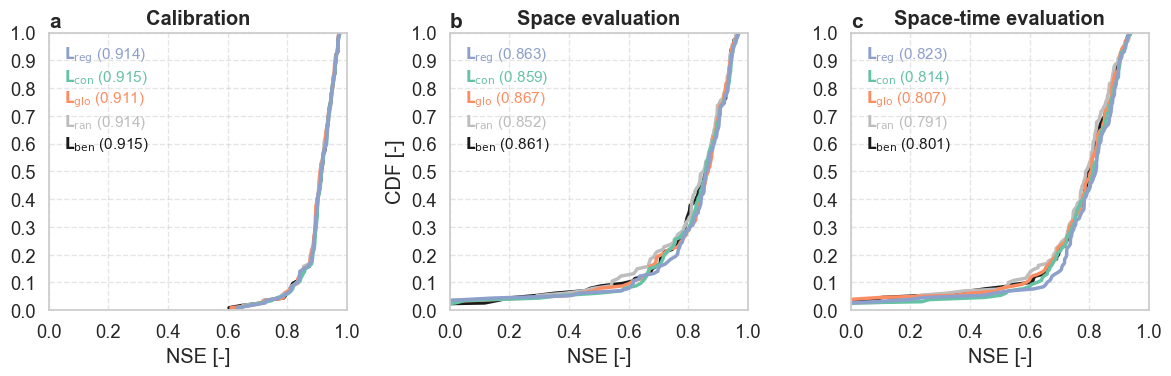

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

# ---- Legend-only panel ----
#axs[0].axis("off")

#for model_type in model_order:
#    axs[0].plot(
#        [],
#        [],
#        color=colors[model_type],
#        linewidth=2.5,
#        label=labels_pretty[model_type]
#    )
#
#axs[0].legend(
#    title="Model experiment",
#    loc="center",
#    frameon=False,
#    fontsize=12,
#    title_fontsize=14
#)

# ---- Calibration evaluation ----
plot_cdf_mean(
    axs[0],
    data_diff_timeval_complete_dict_plot,
    "Calibration",
    "a"
)

# ---- Space evaluation ----
plot_cdf_mean(
    axs[1],
    data_diff_cal_complete_dict_plot,
    "Space evaluation",
    "b"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[2],
    data_diff_val_complete_dict_plot,
    "Space-time evaluation",
    "c"
)

axs[1].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
#plt.savefig(
#    "../results/figs/figures/fig05XX.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

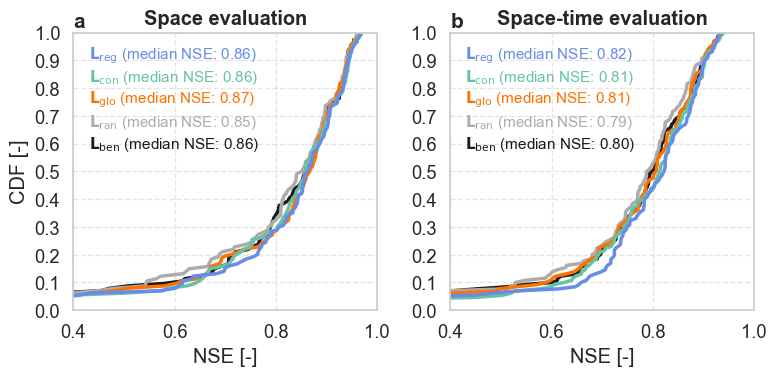

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': "#adacac",
    'nse_nogeo': 'k',
    'nse_g1comp': "#fd7200",
    'nse_c1comp': "#66c2a5",
    'nse_r1comp': "#668de7",
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    # Handle dict or DataFrame input
    if isinstance(data_input, dict):
        dfs = list(data_input.values())
        all_data = pd.concat(dfs, axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict of DataFrames or a single DataFrame.")

    # Mean over repetitions
    data_combined = all_data.groupby(all_data.index).mean()

    medians = {}

    # ---- Plot CDFs ----
    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    # ---- Median text inside plot ----
    y0 = 0.6        # starting vertical position (axes coords)
    dy = 0.08        # vertical spacing

    for i, model_type in enumerate(model_order):
        if model_type not in medians:
            continue

        ax.text(
            0.05,
            y0 + i * dy,
            f"{labels_pretty[model_type]} (median NSE: {medians[model_type]:.2f})",
            transform=ax.transAxes,
            fontsize=11,
            color=colors[model_type],
            ha='left',
            va='center'
        )

    # ---- Axis formatting ----
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0.4, 1)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    # Subplot label
    ax.text(
        0,
        1.075,
        label_letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left'
    )

# -------------------------
# Figure layout
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# ---- Legend-only panel ----
#axs[0].axis("off")

#for model_type in model_order:
#    axs[0].plot(
#        [],
#        [],
#        color=colors[model_type],
#        linewidth=2.5,
#        label=labels_pretty[model_type]
#    )
#
#axs[0].legend(
#    title="Model experiment",
#    loc="center",
#    frameon=False,
#    fontsize=12,
#    title_fontsize=14
#)

# ---- Space evaluation ----
plot_cdf_mean(
    axs[0],
    data_diff_cal_complete_dict_plot,
    "Space evaluation",
    "a"
)

# ---- Space-time evaluation ----
plot_cdf_mean(
    axs[1],
    data_diff_val_complete_dict_plot,
    "Space-time evaluation",
    "b"
)

axs[0].set_ylabel("CDF [-]")

# ---- Save & show ----
plt.tight_layout()
#plt.savefig(
#    "../results/figs/figures/jpgs/fig05.jpg",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

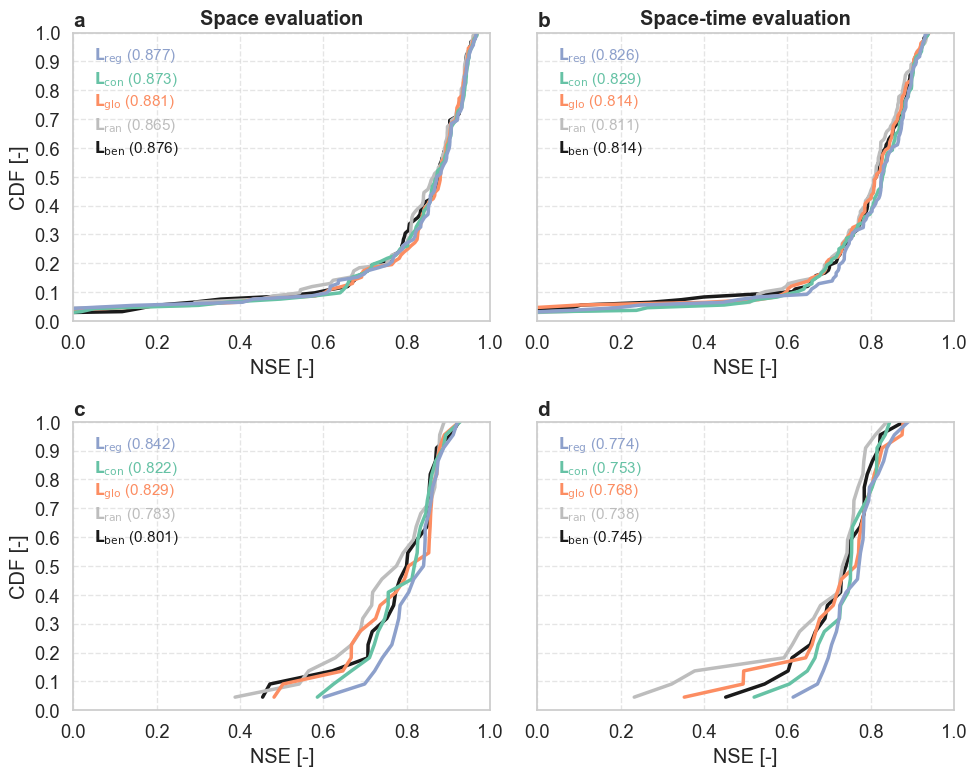

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -------------------------
# Color and label maps
# -------------------------
colors = {
    'nse_ran': '#bdbdbd',
    'nse_nogeo': 'k',
    'nse_g1comp': '#fc8d62',
    'nse_c1comp': '#66c2a5',
    'nse_r1comp': '#8da0cb',
}

labels_pretty = {
    'nse_ran': r"$\mathbf{L_{\mathrm{ran}}}$",
    'nse_nogeo': r"$\mathbf{L_{\mathrm{ben}}}$",
    'nse_g1comp': r"$\mathbf{L_{\mathrm{glo}}}$",
    'nse_c1comp': r"$\mathbf{L_{\mathrm{con}}}$",
    'nse_r1comp': r"$\mathbf{L_{\mathrm{reg}}}$",
}

model_order = [
    'nse_nogeo',
    'nse_ran',
    'nse_g1comp',
    'nse_c1comp',
    'nse_r1comp'
]

# -------------------------
# Plotting function (UNCHANGED)
# -------------------------
def plot_cdf_mean(ax, data_input, title, label_letter):

    if isinstance(data_input, dict):
        all_data = pd.concat(list(data_input.values()), axis=0)
    elif isinstance(data_input, pd.DataFrame):
        all_data = data_input.copy()
    else:
        raise ValueError("data_input must be a dict or DataFrame")

    data_combined = all_data.groupby(all_data.index).mean()
    medians = {}

    for model_type in model_order:
        if model_type not in data_combined.columns:
            continue

        nse_values = np.sort(data_combined[model_type].dropna())
        if len(nse_values) == 0:
            continue

        cumulative = np.arange(1, len(nse_values) + 1) / len(nse_values)

        ax.plot(
            nse_values,
            cumulative,
            color=colors[model_type],
            linewidth=2.5,
            label=labels_pretty[model_type]
        )

        medians[model_type] = np.median(nse_values)

    y0, dy = 0.6, 0.08
    for i, model_type in enumerate(model_order):
        if model_type in medians:
            ax.text(
                0.05, y0 + i * dy,
                f"{labels_pretty[model_type]} ({medians[model_type]:.3f})",
                transform=ax.transAxes,
                fontsize=11,
                color=colors[model_type],
                ha="left", va="center"
            )

    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("NSE [-]")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

    ax.text(
        0, 1.075, label_letter,
        transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="top", ha="left"
    )

# -------------------------
# Figure layout (2x2)
# -------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

basins = {
    "Moselle": network_estreams_moselle_108_gauges.index.tolist(),
    "Garonne": network_estreams_garonne_22_gauges.index.tolist(),
}

labels = ["a", "b", "c", "d"]
panel = 0

for i, (basin_name, basin_ids) in enumerate(basins.items()):

    # ---- Filter data ----
    df_space = data_diff_cal_complete_dict_plot.copy()
    df_space["basin_id"] = df_space.index
    df_space = df_space[df_space["basin_id"].isin(basin_ids)]

    df_space_time = data_diff_val_complete_dict_plot.copy()
    df_space_time["basin_id"] = df_space_time.index
    df_space_time = df_space_time[df_space_time["basin_id"].isin(basin_ids)]

    # ---- Space ----
    plot_cdf_mean(
        axs[i, 0],
        df_space.iloc[:, 0:5],
        f" ",
        labels[panel]
    )
    panel += 1

    # ---- Space-time ----
    plot_cdf_mean(
        axs[i, 1],
        df_space_time.iloc[:, 0:5],
        f" ",
        labels[panel]
    )
    panel += 1
axs[0, 0].set_title("Space evaluation", fontweight="bold")
axs[0, 1].set_title("Space-time evaluation", fontweight="bold")

# Shared y-label
axs[0, 0].set_ylabel("CDF [-]")
axs[1, 0].set_ylabel("CDF [-]")

# Legend (only once)
#axs[0, 1].legend(frameon=False, loc="lower right")

plt.tight_layout()
#plt.savefig(
#    "../results/figs/figures/S8.png",
#    dpi=300,
#    bbox_inches="tight"
#)
plt.show()


In [36]:
def compute_ccc(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return np.nan

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))

    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)


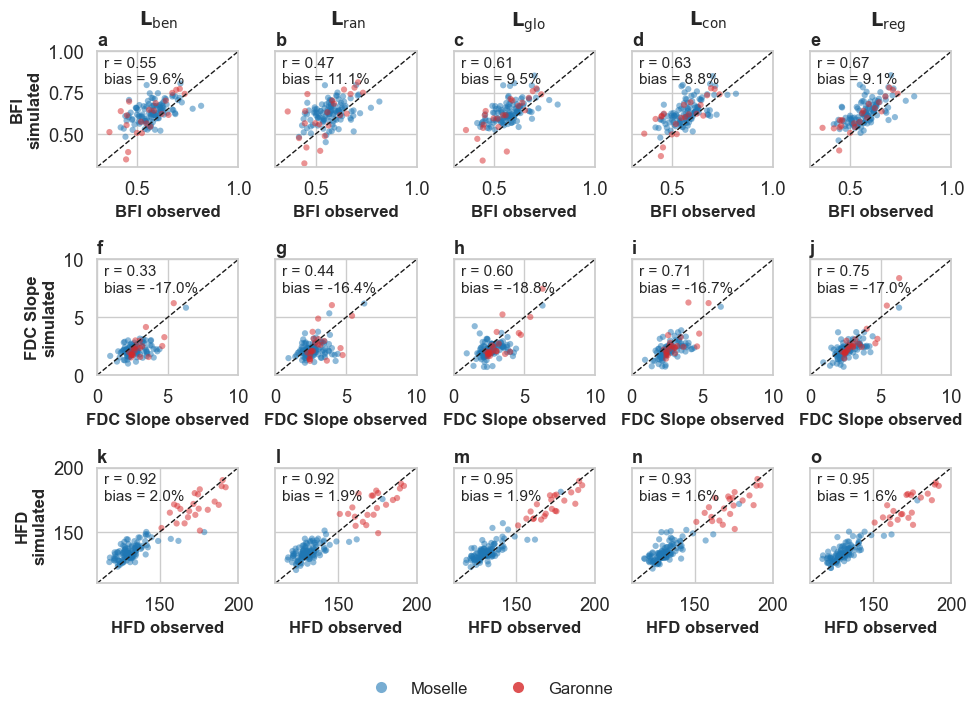

In [25]:
data_diff_complete_dict_plot_scatter = data_diff_val_complete_dict_plot.copy()
#data_diff_complete_dict_plot_scatter = (
#    data_diff_complete_dict_plot_scatter.drop(index="FR001592", errors="ignore")
#)
#
#data_diff_complete_dict_plot_scatter.loc[["FR001592"],
#    ["slope_c1comp", "slope_r1comp", "slope_g1comp", "slope_nogeo", "slope_ran"]
#] = np.nan, np.nan, np.nan, np.nan, np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{ben}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        #bias_rel = (
        #    100
        #    * (data_diff_complete_dict_plot_scatter[var_pred].median()
        #       - data_diff_complete_dict_plot_scatter[var_obs].median())
        #    / data_diff_complete_dict_plot_scatter[var_obs].median()
        #)
        #x = data_diff_complete_dict_plot_scatter[var_obs].values
        #y = data_diff_complete_dict_plot_scatter[var_pred].values

        #R = np.corrcoef(x, y)[0, 1]
        #CCC = compute_ccc(x, y)

        #bias_rel = 100 * (np.nanmedian(y) - np.nanmedian(x)) / np.nanmedian(x)
        x = data_diff_complete_dict_plot_scatter[var_obs]
        y = data_diff_complete_dict_plot_scatter[var_pred]

        bias_rel = 100 * np.nanmedian((y - x) / x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 5 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

## Save
#plt.savefig("../results/figs/figures/jpgs/fig07.jpg", dpi=300)
plt.show()

In [47]:
data_diff_val_complete_dict_plot.to_csv("../results/TableS17_LSTM.csv")
data_diff_cal_complete_dict_plot.to_csv("../results/TableS19_LSTM.csv")

In [ ]:
# Containers
rows = []

for metric in metrics:
    var_obs = f"{metric}_obs"

    for suffix in suffixes:
        var_pred = f"{metric}_{suffix}"

        # Extract vectors
        x = data_diff_complete_dict_plot_scatter[var_obs].values
        y = data_diff_complete_dict_plot_scatter[var_pred].values

        # Spearman correlation
        r_spearman = (
            data_diff_complete_dict_plot_scatter[[var_obs, var_pred]]
            .corr(method="pearson")
            .iloc[0, 1]
        )

        # Relative bias (%)
        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        rows.append({
            "metric": metric,
            "experiment": suffix,
            "r_spearman": r_spearman,
            "bias_%": bias_rel
        })

# Create dataframe
df_stats = pd.DataFrame(rows)

# Pivot for nice table layout (optional)
table_r = df_stats.pivot(index="metric", columns="experiment", values="r_spearman")
table_bias = df_stats.pivot(index="metric", columns="experiment", values="bias_%")

In [35]:
table_r

experiment,c1comp,g1comp,nogeo,r1comp,ran
metric,,,,,
bfi,0.628362,0.607138,0.552987,0.670692,0.466661
hfd,0.931487,0.947265,0.915793,0.948944,0.918123
slope,0.713466,0.600011,0.333059,0.747946,0.442543


In [36]:
table_bias

experiment,c1comp,g1comp,nogeo,r1comp,ran
metric,,,,,
bfi,10.260524,10.474060,10.340609,10.017953,9.753689
hfd,1.572687,1.696540,1.561021,1.306779,1.724926
slope,-14.512936,-16.583628,-2.691971,-15.641323,-3.992679


In [37]:
is_garonne = network_estreams_garonne_22_gauges.index.tolist()
is_moselle = network_estreams_moselle_108_gauges.index.tolist()


In [46]:
data_diff_complete_dict_plot_scatter = data_diff_val_complete_dict_plot.copy()


data_diff_complete_dict_plot_scatter.loc[["FR001592"],
    ["slope_c1comp", "slope_r1comp", "slope_g1comp", "slope_nogeo", "slope_ran"]
] = np.nan, np.nan, np.nan, np.nan, np.nan


rows = []

basins = {
    "Garonne": is_garonne,
    "Moselle": is_moselle,
}

for basin_name, basin_idx in basins.items():

    # Subset once per basin
    df_basin = data_diff_complete_dict_plot_scatter.loc[basin_idx]

    for metric in metrics:
        var_obs = f"{metric}_obs"

        for suffix in suffixes:
            var_pred = f"{metric}_{suffix}"

            # Extract vectors
            x = df_basin[var_obs].values
            y = df_basin[var_pred].values

            # Spearman correlation
            r_spearman = (
                df_basin[[var_obs, var_pred]]
                .corr(method="pearson")
                .iloc[0, 1]
            )

            # Relative bias (%)
            bias_rel = 100 * np.nanmedian((y - x) / x)

            rows.append({
                "basin": basin_name,
                "metric": metric,
                "experiment": suffix,
                "r_spearman": r_spearman,
                "bias_%": bias_rel
            })

# Single tidy dataframe
df_stats = pd.DataFrame(rows)
table_r = df_stats.pivot_table(
    index=["basin", "metric"],
    columns="experiment",
    values="r_spearman"
)


table_r[["nogeo", "ran", "g1comp", "c1comp", "r1comp"]]

experiment         nogeo       ran    g1comp    c1comp    r1comp
basin   metric                                                  
Garonne bfi     0.697081  0.621835  0.727200  0.757476  0.864437
        hfd     0.644589  0.590532  0.839026  0.680785  0.757329
        slope   0.765100  0.658544  0.851182  0.828691  0.871669
Moselle bfi     0.475495  0.382444  0.545272  0.568590  0.593735
        hfd     0.654968  0.712476  0.772634  0.749380  0.813100
        slope   0.493979  0.407220  0.436466  0.661112  0.659160

In [39]:
table_bias = df_stats.pivot_table(
    index=["basin", "metric"],
    columns="experiment",
    values="bias_%"
)
table_bias[["nogeo", "ran", "g1comp", "c1comp", "r1comp"]]

experiment          nogeo        ran     g1comp     c1comp     r1comp
basin   metric                                                       
Garonne bfi      9.861933  12.981347  11.232185   8.502339   8.553234
        hfd     -1.767829  -3.106050  -1.359341  -1.018787  -1.755685
        slope  -21.674091 -17.509893 -21.670158 -20.648731 -17.584455
Moselle bfi      9.473489  11.014887   9.082152   9.098311   9.272661
        hfd      2.295844   2.238845   2.007418   1.904411   1.621412
        slope  -16.124332 -16.404741 -17.832088 -16.653149 -16.231802

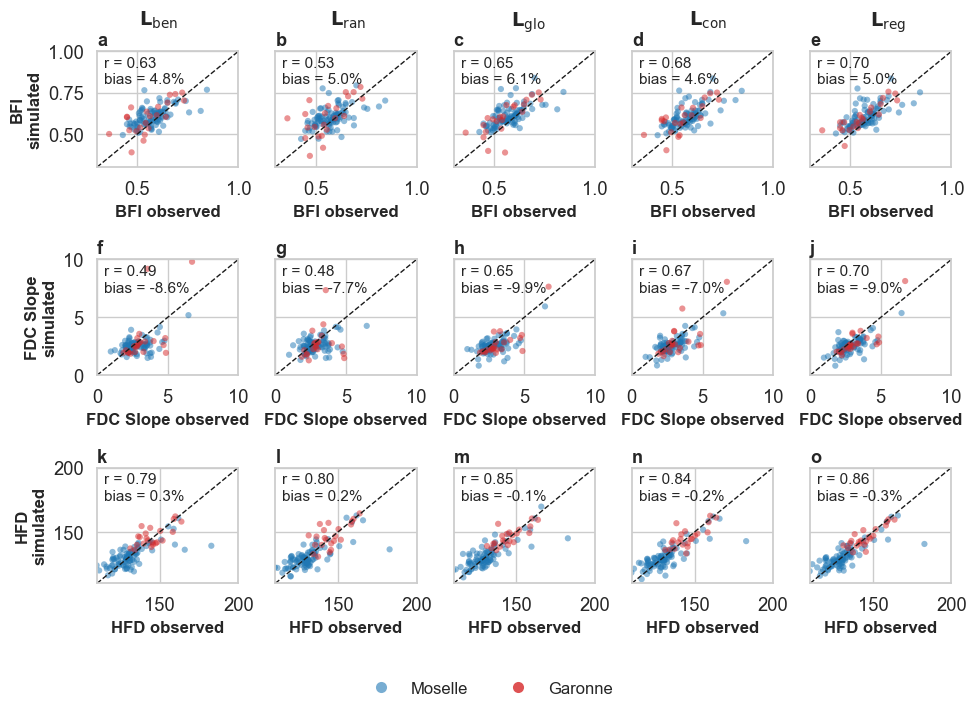

In [57]:
data_diff_cal_complete_dict_plot_scatter = data_diff_cal_complete_dict_plot.copy()

#data_diff_cal_complete_dict_plot_scatter.loc[
#    data_diff_cal_complete_dict_plot_scatter["slope_c1comp"] > 10,
#    "slope_c1comp"
#] = np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{ben}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_cal_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_cal_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_cal_complete_dict_plot_scatter[var_pred].mean()
               - data_diff_cal_complete_dict_plot_scatter[var_obs].mean())
            / data_diff_cal_complete_dict_plot_scatter[var_obs].mean()
        )
        x = data_diff_cal_complete_dict_plot_scatter[var_obs].values
        y = data_diff_cal_complete_dict_plot_scatter[var_pred].values

        R = np.corrcoef(x, y)[0, 1]
        #CCC = compute_ccc(x, y)

        bias_rel = 100 * np.nanmedian((y - x) / x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 5 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
plt.savefig("../results/figs/figures/figS6.png", dpi=300)
plt.show()

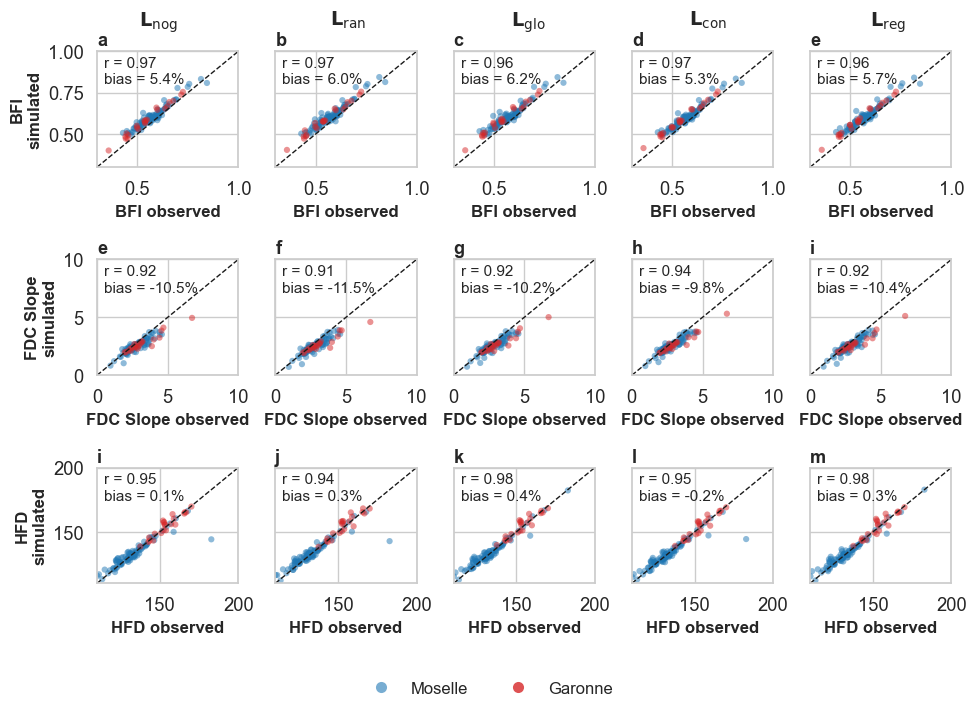

In [59]:
data_diff_cal_complete_dict_plot_scatter = data_diff_timeval_complete_dict_plot.copy()

#data_diff_cal_complete_dict_plot_scatter.loc[
#    data_diff_cal_complete_dict_plot_scatter["slope_c1comp"] > 10,
#    "slope_c1comp"
#] = np.nan

#data_diff_cal_complete_dict_plot_scatter = (
#    data_diff_cal_complete_dict_plot_scatter.drop("FR000144"))


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string

# Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Define variables and pretty titles
metrics = ['bfi', 'slope', 'hfd']
metric_titles = ['BFI', 'FDC Slope', 'HFD']

# Define suffixes and scales
suffixes = ['nogeo', 'ran', 'g1comp', 'c1comp', 'r1comp']
scale_titles = [
    r"$\mathbf{L_{\mathrm{nog}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$"
]

# DEFINE BASIN COLORS
basin_colors = {
    "moselle": "#1f77b4",   # blue
    "garonne": "#d62728",  # red
}

def get_basin_color(gauge_id):
    if gauge_id in network_estreams_moselle_108_gauges.index.tolist():
        return basin_colors["moselle"]
    elif gauge_id in network_estreams_garonne_22_gauges.index.tolist():
        return basin_colors["garonne"]
    else:
        return "grey"  # fallback (should not happen)

# Precompute colors in dataframe order
point_colors = data_diff_cal_complete_dict_plot_scatter.index.map(get_basin_color)

# CREATE SUBPLOTS
fig, axs = plt.subplots(3, 5, figsize=(10, 7), sharex=False, sharey=False)
letters = list(string.ascii_lowercase)

for row, (metric, row_title) in enumerate(zip(metrics, metric_titles)):
    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row, col]

        var_obs  = f"{metric}_obs"
        var_pred = f"{metric}_{suffix}"

        # Moselle
        moselle_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=1
        )

        # Garonne
        garonne_mask = data_diff_cal_complete_dict_plot_scatter.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_obs],
            data_diff_cal_complete_dict_plot_scatter.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            edgecolor='none',
            linewidth=0.1,
            alpha=0.5,
            zorder=2
        )


        # Labels
        if col == 0:
            ax.set_ylabel(f"{row_title}\nsimulated", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        ax.set_xlabel(f"{row_title} observed", fontsize=12, fontweight='bold')

        # Correlation & bias
        p = data_diff_cal_complete_dict_plot_scatter[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias_rel = (
            100
            * (data_diff_cal_complete_dict_plot_scatter[var_pred].mean()
               - data_diff_cal_complete_dict_plot_scatter[var_obs].mean())
            / data_diff_cal_complete_dict_plot_scatter[var_obs].mean()
        )
        x = data_diff_cal_complete_dict_plot_scatter[var_obs].values
        y = data_diff_cal_complete_dict_plot_scatter[var_pred].values

        R = np.corrcoef(x, y)[0, 1]

        bias_rel = 100 * (np.nanmean(y) - np.nanmean(x)) / np.nanmean(x)

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias_rel:.1f}%",
            #f"rs = {p:.2f}\nCCC = {CCC:.2f}\nbias = {bias_rel:.1f}%",

            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none')
        )


        # Subplot letter
        subplot_idx = row * 4 + col
        ax.text(
            0.00, 1.17, letters[subplot_idx],
            transform=ax.transAxes,
            fontsize=13,
            fontweight='bold',
            va='top',
            ha='left'
        )

        # Axis limits
        if metric == 'bfi':
            ax.set_xlim(0.3, 1)
            ax.set_ylim(0.3, 1)
            ax.plot([0.3, 1], [0.3, 1], 'k--', lw=1)
        elif metric == 'slope':
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.plot([0, 10], [0, 10], 'k--', lw=1)
        elif metric == 'hfd':
            ax.set_xlim(110, 200)
            ax.set_ylim(110, 200)
            ax.plot([110, 200], [110, 200], 'k--', lw=1)

# LEGEND (INSTEAD OF COLORBAR)
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Moselle',
           markerfacecolor=basin_colors["moselle"], markersize=8, markeredgecolor='none', alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='Garonne',
           markerfacecolor=basin_colors["garonne"], markersize=8, markeredgecolor='none', alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12
)

# Column titles
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 1, title, ha='center', va='top',
             fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.18)

# Save
plt.savefig("../results/figs/figures/FigSX_signatures_lstm_time.png", dpi=300)
plt.show()

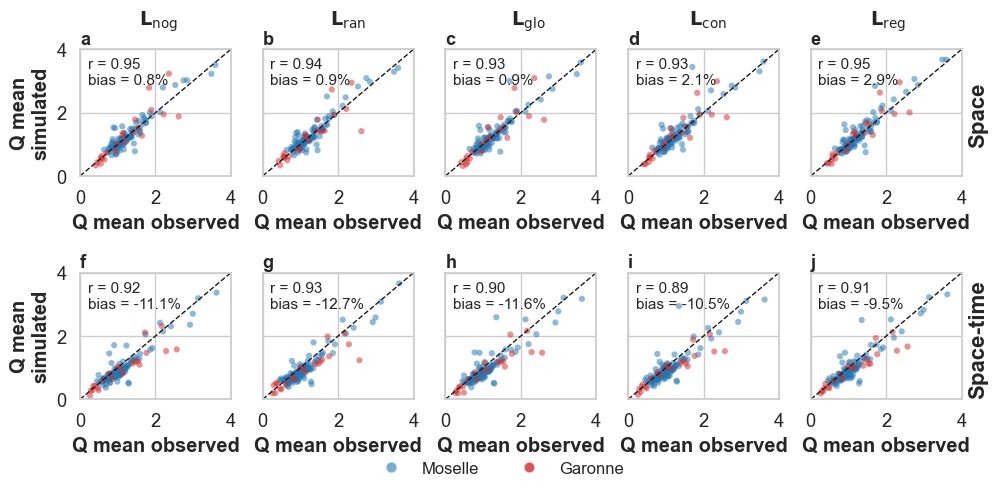

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import string
from matplotlib.lines import Line2D

sns.set(style="whitegrid", font_scale=1.2)

# =========================
# CONFIG
# =========================
metrics = ["qmean"]
metric_titles = ["Q mean"]

suffixes = ["nogeo", "ran", "g1comp", "c1comp", "r1comp"]
scale_titles = [
    r"$\mathbf{L_{\mathrm{nog}}}$",
    r"$\mathbf{L_{\mathrm{ran}}}$",
    r"$\mathbf{L_{\mathrm{glo}}}$",
    r"$\mathbf{L_{\mathrm{con}}}$",
    r"$\mathbf{L_{\mathrm{reg}}}$",
]

basin_colors = {
    "moselle": "#1f77b4",
    "garonne": "#d62728",
}

letters = list(string.ascii_lowercase)

# =========================
# FIGURE SETUP
# =========================
fig, axs = plt.subplots(
    2, 5,
    figsize=(10, 5),
    sharex=False,
    sharey=False
)

# =========================
# LOOP OVER ROWS
# =========================
for row_idx, (df, row_title) in enumerate([
    (data_diff_cal_complete_dict_plot, "Space evaluation"),
    (data_diff_val_complete_dict_plot, "Space–time evaluation"),
]):

    for col, (suffix, scale_title) in enumerate(zip(suffixes, scale_titles)):
        ax = axs[row_idx, col]

        var_obs  = "qmean_obs"
        var_pred = f"qmean_{suffix}"

        # Moselle
        moselle_mask = df.index.isin(
            network_estreams_moselle_108_gauges.index
        )

        ax.scatter(
            df.loc[moselle_mask, var_obs],
            df.loc[moselle_mask, var_pred],
            c=basin_colors["moselle"],
            s=20,
            alpha=0.5,
            edgecolor="none",
            zorder=1,
        )

        # Garonne
        garonne_mask = df.index.isin(
            network_estreams_garonne_22_gauges.index
        )

        ax.scatter(
            df.loc[garonne_mask, var_obs],
            df.loc[garonne_mask, var_pred],
            c=basin_colors["garonne"],
            s=20,
            alpha=0.5,
            edgecolor="none",
            zorder=2,
        )

        # Labels
        if col == 0:
            ax.set_ylabel("Q mean\nsimulated", fontweight="bold")
        else:
            ax.set_yticklabels([])

        ax.set_xlabel("Q mean observed", fontweight="bold")

        # Stats
        p = df[[var_obs, var_pred]].corr(method="pearson").iloc[0, 1]
        bias = 100 * (np.nanmean(df[var_pred]) - np.nanmean(df[var_obs])) / np.nanmean(df[var_obs])

        ax.text(
            0.05, 0.72,
            f"r = {p:.2f}\nbias = {bias:.1f}%",
            transform=ax.transAxes,
            fontsize=11,
        )

        # 1:1 line
        ax.set_xlim(0, 4)
        ax.set_ylim(0, 4)
        ax.plot([0, 4], [0, 4], "k--", lw=1)

        # Subplot letter
        ax.text(
            0.00, 1.15,
            letters[row_idx * 5 + col],
            transform=ax.transAxes,
            fontweight="bold",
            fontsize=13,
            va="top",
            ha="left",
        )

# =========================
# COLUMN TITLES
# =========================
col_positions = [0.17, 0.36, 0.54, 0.72, 0.9]
for x, title in zip(col_positions, scale_titles):
    fig.text(x, 0.96, title, ha="center", va="top",
             fontsize=14, fontweight="bold")

# =========================
# ROW TITLES
# =========================
# =========================
# ROW TITLES (VERTICAL, RIGHT SIDE)
# =========================
fig.text(
    1, 0.75, "Space",
    rotation=90,
    va="center",
    ha="right",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    1, 0.3, "Space-time",
    rotation=90,
    va="center",
    ha="right",
    fontsize=16,
    fontweight="bold"
)

# =========================
# LEGEND
# =========================
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Moselle",
           markerfacecolor=basin_colors["moselle"], markersize=8, alpha=0.6),
    Line2D([0], [0], marker="o", color="w", label="Garonne",
           markerfacecolor=basin_colors["garonne"], markersize=8, alpha=0.8),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=12,
)

# =========================
# FINALIZE
# =========================
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.18)

plt.savefig(
    "../results/figs/figures/FigS12.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Check the other signatures

In [401]:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

# ===============================
# NeuralHydrology signature imports
# ===============================
from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
    q5,
    q95,
    high_q_dur,
    high_q_freq,
    low_q_dur,
    low_q_freq,
    zero_q_freq,
)

# ===============================
# LOAD SIMULATIONS (MULTI-SEED)
# ===============================
files = [
    "../results/sim_lstm/space-time/simu_Seed_28.nc",
    "../results/sim_lstm/space-time/simu_Seed_33.nc",
    "../results/sim_lstm/space-time/simu_Seed_44.nc",
    "../results/sim_lstm/space-time/simu_Seed_55.nc",
    "../results/sim_lstm/space-time/simu_Seed_77.nc",
]

seeds = [28, 33, 44, 55, 77]

datasets = []
for seed, f in zip(seeds, files):
    ds_seed = xr.open_dataset(f).expand_dims(seed=[seed])
    datasets.append(ds_seed)

ds_all = xr.concat(datasets, dim="seed")
ds = ds_all.mean(dim="seed")

# ===============================
# TIME WINDOW + GAUGES
# ===============================
start_date = "2002-10-01"
end_date   = "2015-09-30"

selected_gauge_ids = network_estreams_garonne_and_moselle.index.unique().tolist()

ds_clipped = ds.sel(
    gauge_id=selected_gauge_ids,
    date=slice(start_date, end_date)
)

# ===============================
# SOURCES
# ===============================
sources = [
    "observation",
    "regional",
    "continental",
    "global",
    "nogeology",
    "random",
]

source_map = {
    "observation": "obs",
    "regional": "r1comp",
    "continental": "c1comp",
    "global": "g1comp",
    "nogeology": "nogeo",
    "random": "ran",
}

# ===============================
# SAFETY MASK
# ===============================
MIN_VALID_POINTS = 365

def mask_sim(sim, obs):
    sim = sim.where(~np.isnan(obs))
    if sim.count() < MIN_VALID_POINTS:
        return None
    return sim

# ===============================
# SIGNATURE COMPUTATION
# ===============================
signature_results = []

for gauge in tqdm.tqdm(ds_clipped.gauge_id.values):
    obs = ds_clipped.sel(gauge_id=gauge)["observation"]
    row = {"gauge_id": gauge}

    for src in sources:
        sim = ds_clipped.sel(gauge_id=gauge)[src]
        sim = mask_sim(sim, obs)

        if sim is None:
            for key in [
                "qmean", "q5", "q95", "slope",
                "hfd", "bfi",
                "hqd", "hqf",
                "lqd", "lqf",
                "zeroq",
            ]:
                row[f"{key}_{source_map[src]}"] = np.nan
            continue

        try:
            row[f"qmean_{source_map[src]}"] = q_mean(sim)
        except:
            row[f"qmean_{source_map[src]}"] = np.nan

        try:
            row[f"q5_{source_map[src]}"] = q5(sim)
        except:
            row[f"q5_{source_map[src]}"] = np.nan

        try:
            row[f"q95_{source_map[src]}"] = q95(sim)
        except:
            row[f"q95_{source_map[src]}"] = np.nan

        try:
            row[f"slope_{source_map[src]}"] = slope_fdc(sim)
        except:
            row[f"slope_{source_map[src]}"] = np.nan

        try:
            row[f"hfd_{source_map[src]}"] = hfd_mean(sim, datetime_coord="date")
        except:
            row[f"hfd_{source_map[src]}"] = np.nan

        try:
            row[f"bfi_{source_map[src]}"] = baseflow_index(
                sim, alpha=0.925, warmup=365, n_passes=3
            )[0]
        except:
            row[f"bfi_{source_map[src]}"] = np.nan

        try:
            row[f"hqd_{source_map[src]}"] = high_q_dur(sim)
        except:
            row[f"hqd_{source_map[src]}"] = np.nan

        try:
            row[f"hqf_{source_map[src]}"] = high_q_freq(sim)
        except:
            row[f"hqf_{source_map[src]}"] = np.nan

        try:
            row[f"lqd_{source_map[src]}"] = low_q_dur(sim)
        except:
            row[f"lqd_{source_map[src]}"] = np.nan

        try:
            row[f"lqf_{source_map[src]}"] = low_q_freq(sim)
        except:
            row[f"lqf_{source_map[src]}"] = np.nan

        try:
            row[f"zeroq_{source_map[src]}"] = zero_q_freq(sim)
        except:
            row[f"zeroq_{source_map[src]}"] = np.nan

    signature_results.append(row)

# ===============================
# FINAL DATAFRAME
# ===============================
signature_df = pd.DataFrame(signature_results)
signature_df.set_index("gauge_id", inplace=True)

# ===============================
# MERGE WITH NSE / KGE RESULTS
# ===============================
signature_df

100%|██████████| 130/130 [00:18<00:00,  6.90it/s]


,qmean_obs,q5_obs,q95_obs,slope_obs,hfd_obs,bfi_obs,hqd_obs,hqf_obs,lqd_obs,lqf_obs,...,q5_ran,q95_ran,slope_ran,hfd_ran,bfi_ran,hqd_ran,hqf_ran,lqd_ran,lqf_ran,zeroq_ran
gauge_id,,,,,,,,,,,,,,,,,,,,,
FR004136,2.166707,0.28,6.5195,2.652936,182.000000,0.623818,1.647059,1.833333,7.237500,46.416667,...,0.241890,6.266807,3.157465,171.416667,0.617653,1.565217,2.750000,14.288136,67.916667,0.000000
FR001547,0.842004,0.07,3.2765,3.108645,156.166667,0.416481,2.769231,21.500000,16.586207,113.500000,...,0.071745,2.301427,3.175063,149.166667,0.476888,2.540230,16.500000,8.237762,91.583333,0.000000
FR004091,2.564942,0.58,7.1930,2.594268,171.833333,0.639218,1.380952,1.916667,3.473684,5.500000,...,0.541897,2.549205,1.198109,176.416667,0.769512,1.500000,0.500000,NaN,0.000000,0.000000
FR001592,0.264454,0.01,0.8600,5.256370,157.333333,0.452710,5.344828,22.583333,21.060000,165.750000,...,0.000000,0.965803,6.154612,174.083333,0.424741,13.313433,69.916667,13.994624,200.583333,0.137742
FR001577,0.988105,0.05,3.9385,4.731017,153.166667,0.446811,3.554348,25.000000,21.178571,136.333333,...,0.221524,2.788973,2.405281,161.166667,0.638311,2.040000,3.916667,3.826087,6.916667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,1.040731,0.12,3.6565,2.881746,125.833333,0.501335,3.044444,10.166667,9.139535,58.833333,...,0.252051,2.614428,1.914561,133.083333,0.638059,2.285714,3.500000,NaN,0.000000,0.000000
FR003271,0.624199,0.10,2.5665,2.505086,123.833333,0.546936,5.451613,13.750000,13.320755,51.916667,...,0.079110,1.649026,2.370765,125.750000,0.537708,3.897959,14.666667,2.114286,26.166667,0.000000
FR003301,0.788065,0.14,2.7775,2.822904,128.500000,0.552426,2.672414,12.500000,5.293333,27.666667,...,0.172034,2.173418,2.003049,130.666667,0.597759,2.333333,7.500000,2.242424,5.250000,0.000000


In [404]:
signature_df[["q5_obs", "q5_nogeo", "q5_g1comp", "q5_c1comp", "q5_r1comp"]].corr()[["q5_obs"]]

,q5_obs
q5_obs,1.000000
q5_nogeo,0.634355
q5_g1comp,0.614289
q5_c1comp,0.645482
q5_r1comp,0.667358


In [395]:
signature_df[["q95_obs", "q95_nogeo", "q95_g1comp", "q95_c1comp", "q95_r1comp"]].corr()[["q95_obs"]]

,q95_obs
q95_obs,1.000000
q95_nogeo,0.893151
q95_g1comp,0.884855
q95_c1comp,0.905893
q95_r1comp,0.925743


In [403]:
signature_df[["bfi_obs", "bfi_nogeo", "bfi_g1comp", "bfi_c1comp", "bfi_r1comp"]].corr()[["bfi_obs"]]

,bfi_obs
bfi_obs,1.000000
bfi_nogeo,0.560503
bfi_g1comp,0.616767
bfi_c1comp,0.633193
bfi_r1comp,0.679378


In [397]:
signature_df[["hqd_obs", "hqd_nogeo", "hqd_g1comp", "hqd_c1comp", "hqd_r1comp"]].corr()[["hqd_obs"]]

,hqd_obs
hqd_obs,1.000000
hqd_nogeo,0.493953
hqd_g1comp,0.451494
hqd_c1comp,0.605170
hqd_r1comp,0.638420


In [398]:
signature_df[["lqd_obs", "lqd_nogeo", "lqd_g1comp", "lqd_c1comp", "lqd_r1comp"]].corr()[["lqd_obs"]]

,lqd_obs
lqd_obs,1.000000
lqd_nogeo,0.361297
lqd_g1comp,0.393629
lqd_c1comp,0.332145
lqd_r1comp,0.406915


In [399]:
signature_df[["lqf_obs", "lqf_nogeo", "lqf_g1comp", "lqf_c1comp", "lqf_r1comp"]].corr()[["lqf_obs"]]

,lqf_obs
lqf_obs,1.000000
lqf_nogeo,0.445951
lqf_g1comp,0.413082
lqf_c1comp,0.566270
lqf_r1comp,0.601323


In [400]:
signature_df[["hqf_obs", "hqf_nogeo", "hqf_g1comp", "hqf_c1comp", "hqf_r1comp"]].corr()[["hqf_obs"]]

,hqf_obs
hqf_obs,1.000000
hqf_nogeo,0.500538
hqf_g1comp,0.551223
hqf_c1comp,0.569345
hqf_r1comp,0.599493


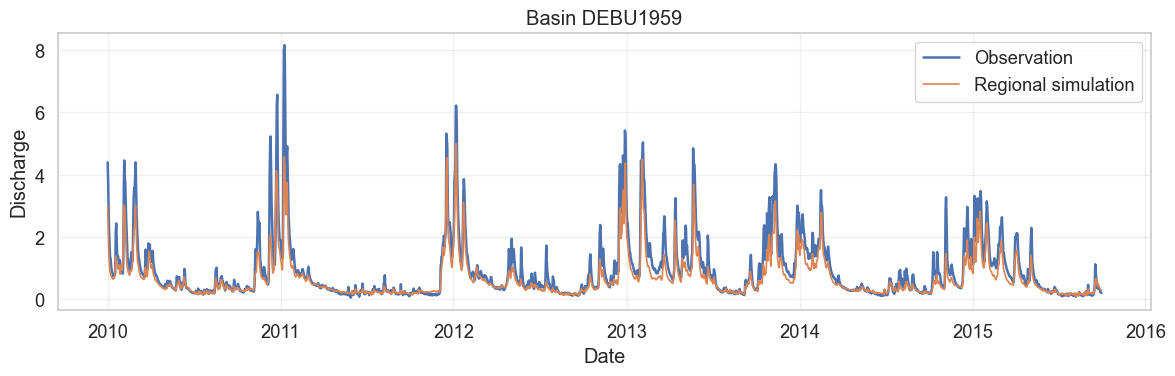

0.8837206363677979


In [114]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df



df = basin_timeseries_df(
    ds_clipped,
    basin_id="DEBU1958",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds_clipped,
    basin_id="DEBU1959",
    start="2010-01-01",
    end="2020-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

In [115]:
import matplotlib.pyplot as plt

def plot_timeseries_multi(
    ds,
    basin_id,
    sim_vars,
    labels=None,
    start=None,
    end=None,
    figsize=(12, 4),
):
    """
    Plot observation vs multiple simulations for one basin.

    Parameters
    ----------
    ds : xarray.Dataset
    basin_id : str
    sim_vars : list of str
        Variable names in ds for simulations (e.g. ["regional", "global"])
    labels : list of str, optional
        Labels for legend (same length as sim_vars)
    start, end : str or None
        Date range
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    if labels is None:
        labels = sim_vars

    plt.figure(figsize=figsize)

    # Observation
    plt.plot(
        da.date,
        da["observation"],
        label="Observation",
        linewidth=2.0,
    )

    # Simulations
    for var, lab in zip(sim_vars, labels):
        plt.plot(
            da.date,
            da[var],
            label=lab,
            linewidth=1.3,
        )

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [132]:
data_diff_val_complete_dict_plot.iloc[20:40]

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004143,0.764657,0.737968,0.783515,0.767067,0.777226,0.748251,0.715342,0.798545,0.711857,0.744920,...,1.905518,2.131983,2.044606,2.004057,1.361640,1.172385,1.142916,1.182740,1.147022,1.119662
FR001604,0.696415,0.731656,0.681463,0.743120,0.736190,0.448086,0.490324,0.447374,0.488994,0.448426,...,1.484185,1.405498,1.639066,1.753348,1.125220,0.888177,0.922629,0.830099,0.839060,0.861464
LU000018,0.734649,0.678278,0.654852,0.592413,0.740874,0.583159,0.492264,0.649404,0.308498,0.588805,...,0.926435,2.848018,1.907819,1.868495,0.895366,0.786901,0.721150,0.722175,0.748590,0.686632
LU000010,-0.456054,0.619910,-0.285612,0.209713,0.348592,-0.123631,0.453124,-0.097185,0.353910,0.403458,...,1.561509,3.496908,1.742180,1.631566,0.926466,1.411489,1.500261,1.688525,1.889999,0.621671
LU000001,0.860644,0.805286,0.841962,0.869620,0.861651,0.788806,0.804282,0.746375,0.724585,0.778036,...,3.082768,3.424144,3.876877,5.847762,1.192124,0.958100,0.938835,0.961518,0.964556,0.971120
DERP2028,0.702502,0.808668,0.800005,0.800478,0.788309,0.623812,0.638480,0.748292,0.558431,0.539643,...,1.363857,2.363596,2.309914,1.300314,0.982784,0.786259,0.773601,0.811075,0.705577,0.829182
FR000183,0.410820,-0.546880,0.577109,0.427791,0.392512,0.677172,0.487334,0.725467,0.646996,0.701909,...,2.658018,2.206136,2.256193,4.648703,1.116936,0.839389,0.762390,0.855033,0.827764,0.577903
DERP2008,0.802588,0.721079,0.797380,0.805886,0.811879,0.546874,0.455044,0.513239,0.548313,0.562439,...,2.638532,2.383521,2.387437,2.102407,0.964844,0.731240,0.726745,0.701288,0.731028,0.683956
FR000137,0.870995,0.855900,0.878425,0.869231,0.866732,0.823213,0.796459,0.818450,0.863913,0.853285,...,2.612672,2.636204,2.518432,3.511234,0.984974,0.909534,0.920694,0.908867,0.906491,0.849526
FR003294,0.795331,0.780121,0.816229,0.769662,0.806428,0.610286,0.611380,0.627972,0.498302,0.571988,...,2.479739,2.141016,2.025559,2.040050,0.833805,0.737890,0.707828,0.772119,0.792592,0.787922


In [185]:
data_diff_val_complete_dict_plot.index.tolist()[90:120]

['FR003288',
 'FR000174',
 'DERP2021',
 'FR003293',
 'FR003236',
 'BEWA0119',
 'DERP2013',
 'DERP2024',
 'FR003283',
 'FR000159',
 'FR003284',
 'LU000019',
 'LU000015',
 'FR003259',
 'DERP2015',
 'FR003274',
 'DERP2036',
 'DERP2011',
 'BEWA0066',
 'FR003275',
 'FR003257',
 'FR003296',
 'FR000171',
 'FR000140',
 'DEBU1956',
 'LU000002',
 'LU000016',
 'FR003250',
 'FR000132',
 'FR003254']

In [ ]:
BASIN_ID = "BEWA0106"
BASIN_ID = "LU000017"
BASIN_ID = "BEWA0107"
BASIN_ID = "BEWA0119"
BASIN_ID = "DERP2024"
BASIN_ID = "BEWA0066"
BASIN_ID = "LU000002"
BASIN_ID = "DERP2013"

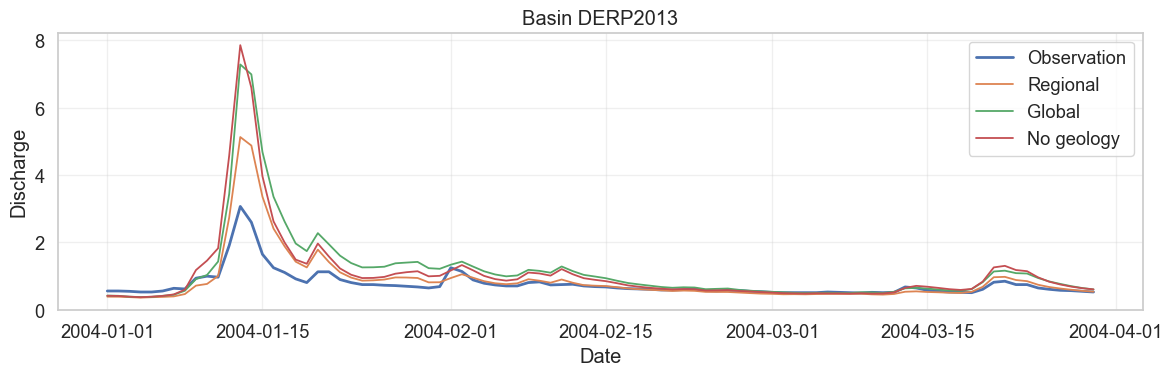

In [220]:
plot_timeseries_multi(
    ds_clipped,
    basin_id=BASIN_ID,
    sim_vars=["regional", "global", "nogeology"],
    labels=["Regional", "Global", "No geology"],
    start="2004-01-01",
    end="2004-03-30",
)

In [221]:
data_diff_val_complete_dict_plot.loc[BASIN_ID][["bfi_obs", "bfi_r1comp", "bfi_c1comp", "bfi_g1comp", "bfi_nogeo"]]

bfi_obs       0.815621
bfi_r1comp    0.750197
bfi_c1comp    0.712668
bfi_g1comp    0.655827
bfi_nogeo     0.661168
Name: DERP2013, dtype: float64

## Technical validation with CAMELS-DE

In [475]:
# German basins only
network_DE = network_estreams_moselle_108_gauges[network_estreams_moselle_108_gauges.gauge_country == "DE"]

In [476]:
import pandas as pd
from rapidfuzz import process, fuzz
import unicodedata, re

# 1. Normalization helpers
def normalize_text(s):
    """Remove accents, punctuation, lowercase."""
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s

def normalize_id(s):
    """Digits only, strip trailing zeros (e.g., 5717000000 → 5717)."""
    if pd.isna(s):
        return ""
    s = re.sub(r"\D", "", str(s))
    return s.rstrip("0")

# 2. Prepare data
network_estreams_de = network_DE[network_DE.gauge_country=="DE"]
camels = pd.read_csv("/Users/nascimth/Downloads/camels_de/CAMELS_DE_topographic_attributes.csv", index_col=0)
camels["gauge_id"] = camels.index
camels.index.name = "index"

estreams = network_estreams_de[["gauge_id", "gauge_name", "river"]].copy()

# The index here is basin_id — DO NOT overwrite it.
estreams["combined_name"] = (
    estreams["gauge_name"].fillna("") + " " + estreams["river"].fillna("")
).str.strip()

# Normalized columns
estreams["norm_id"] = estreams["gauge_id"].apply(normalize_id)
estreams["norm_name"] = estreams["gauge_name"].apply(normalize_text)
estreams["norm_combined"] = estreams["combined_name"].apply(normalize_text)

camels = camels[["gauge_id", "provider_id", "gauge_name", "water_body_name"]].copy()
camels["combined_name"] = (camels["gauge_name"].fillna("") + " " +
                           camels["water_body_name"].fillna("")).str.strip()

camels["norm_id"] = camels["provider_id"].apply(normalize_id)
camels["norm_name"] = camels["gauge_name"].apply(normalize_text)
camels["norm_combined"] = camels["combined_name"].apply(normalize_text)

# 3. Exact matches (ID, name, combined)
def exact_match(left, right, left_on, right_on, match_type):
    m = pd.merge(
        left, right,
        left_on=left_on,
        right_on=right_on,
        how="inner",
        suffixes=("_camels", "_estreams")
    )
    if "gauge_id_camels" in m.columns:
        m.rename(columns={"gauge_id_camels": "gauge_id"}, inplace=True)
    if "gauge_id" not in m.columns:
        m["gauge_id"] = None
    if not m.empty:
        m["match_type"] = match_type
    return m

matches = []
matches.append(exact_match(camels, estreams, "norm_id", "norm_id", "ID (normalized)"))
matches.append(exact_match(camels, estreams, "norm_name", "norm_name", "Name (normalized)"))
matches.append(exact_match(camels, estreams, "norm_combined", "norm_combined", "Combined name (normalized)"))

exact_matches = pd.concat(matches, ignore_index=True)
exact_matches = exact_matches.drop_duplicates(subset=["gauge_id"])
matched_camels_ids = set(exact_matches["gauge_id"].dropna().unique())

# 4. Fuzzy fallback for unmatched ones
unmatched_camels = camels[~camels["gauge_id"].isin(matched_camels_ids)].copy()
fuzzy_matches = []

for _, row in unmatched_camels.iterrows():
    name = row["norm_combined"]
    if not name:
        continue
    best = process.extractOne(name, estreams["norm_combined"], scorer=fuzz.token_sort_ratio)
    if best and best[1] >= 85:
        matched_row = estreams.loc[estreams["norm_combined"] == best[0]].iloc[0]
        fuzzy_matches.append({
            "gauge_id": row["gauge_id"],
            "estreams_id": matched_row.name,
            "camels_name": row["combined_name"],
            "estreams_name": matched_row["combined_name"],
            "similarity": best[1],
            "match_type": "Fuzzy (normalized)"
        })

fuzzy_matches = pd.DataFrame(fuzzy_matches)

# 5. Combine all matches & build rename dictionary (corrected)

# Preserve the EStreams index as 'basin_id' without duplicating 'gauge_id'
estreams_reset = estreams.copy()
estreams_reset["basin_id"] = estreams_reset.index  # keep basin_id explicitly

# Re-run the exact_match function with this updated estreams
def exact_match(left, right, left_on, right_on, match_type):
    m = pd.merge(
        left,
        right,
        left_on=left_on,
        right_on=right_on,
        how="inner",
        suffixes=("_camels", "_estreams")
    )
    if "gauge_id_camels" in m.columns:
        m.rename(columns={"gauge_id_camels": "gauge_id"}, inplace=True)
    if not m.empty:
        m["match_type"] = match_type
    return m

# Redo exact matches
matches = []
matches.append(exact_match(camels, estreams_reset, "norm_id", "norm_id", "ID (normalized)"))
matches.append(exact_match(camels, estreams_reset, "norm_name", "norm_name", "Name (normalized)"))
matches.append(exact_match(camels, estreams_reset, "norm_combined", "norm_combined", "Combined name (normalized)"))

exact_matches = pd.concat(matches, ignore_index=True)
exact_matches = exact_matches.drop_duplicates(subset=["gauge_id"])
matched_camels_ids = set(exact_matches["gauge_id"].dropna().unique())

# Fuzzy matches (same logic)
unmatched_camels = camels[~camels["gauge_id"].isin(matched_camels_ids)].copy()
fuzzy_matches = []
for _, row in unmatched_camels.iterrows():
    name = row["norm_combined"]
    if not name:
        continue
    best = process.extractOne(name, estreams["norm_combined"], scorer=fuzz.token_sort_ratio)
    if best and best[1] >= 85:
        matched_row = estreams.loc[estreams["norm_combined"] == best[0]].iloc[0]
        fuzzy_matches.append({
            "gauge_id": row["gauge_id"],
            "estreams_id": matched_row.name,  # index = basin_id
            "camels_name": row["combined_name"],
            "estreams_name": matched_row["combined_name"],
            "similarity": best[1],
            "match_type": "Fuzzy (normalized)"
        })
fuzzy_matches = pd.DataFrame(fuzzy_matches)

# Build final mapping
exact_matches["estreams_id"] = exact_matches["basin_id"]

mapping = pd.concat([exact_matches[["gauge_id", "estreams_id", "match_type"]], fuzzy_matches], ignore_index=True)
mapping = mapping.dropna(subset=["estreams_id"])
mapping = mapping.drop_duplicates(subset=["gauge_id"])

rename_dict = mapping.set_index("gauge_id")["estreams_id"].to_dict()

# Print summary
print("=== Match summary ===")
print(mapping["match_type"].value_counts())
print(f"\nMatched: {len(rename_dict)}/{len(camels)} ({len(rename_dict)/len(camels):.1%})")

# Check a few mappings
print("\nExample rename_dict entries:")
for k, v in list(rename_dict.items())[:10]:
    print(f"{k} → {v}")

=== Match summary ===
match_type
ID (normalized)    16
Name: count, dtype: int64

Matched: 16/1582 (1.0%)

Example rename_dict entries:
DEB10130 → DERP2013
DEB10340 → DERP2036
DEB10900 → DERP2005
DEB10910 → DERP2006
DEB10940 → DERP2007
DEB10950 → DERP2008
DEB10970 → DERP2010
DEB10980 → DERP2011
DEB11010 → DERP2017
DEB11020 → DERP2018


In [477]:
rename_dict

{'DEB10130': 'DERP2013',
 'DEB10340': 'DERP2036',
 'DEB10900': 'DERP2005',
 'DEB10910': 'DERP2006',
 'DEB10940': 'DERP2007',
 'DEB10950': 'DERP2008',
 'DEB10970': 'DERP2010',
 'DEB10980': 'DERP2011',
 'DEB11010': 'DERP2017',
 'DEB11020': 'DERP2018',
 'DEB11110': 'DERP2027',
 'DEB11120': 'DERP2028',
 'DEB11130': 'DERP2029',
 'DEB11140': 'DERP2030',
 'DEB11150': 'DERP2031',
 'DEB11180': 'DERP2033'}

In [478]:
data_diff_timeval_complete_dict_plot

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004136,0.669755,0.678249,0.683081,0.680154,0.676096,0.563582,0.594021,0.597832,0.596808,0.583273,...,2.351846,2.269471,2.153699,2.232011,2.164676,1.702373,1.711115,1.738528,1.667284,1.693179
FR001547,0.818005,0.829254,0.819462,0.821860,0.822863,0.772873,0.830559,0.779140,0.789951,0.787768,...,2.830713,2.648390,2.851773,2.895733,0.834606,0.806548,0.825703,0.808343,0.803193,0.837438
FR004091,0.714085,0.718700,0.713530,0.709313,0.720225,0.746219,0.774726,0.746116,0.740150,0.732633,...,2.047963,2.138593,2.138954,2.162572,2.553183,2.332357,2.331494,2.317246,2.303061,2.350829
FR001592,0.599082,0.589886,0.567664,0.589826,0.568468,0.446223,0.458726,0.425571,0.448692,0.445003,...,2.074900,2.126999,2.187754,1.974919,0.253320,0.210900,0.205424,0.213876,0.205789,0.220506
FR001577,0.856133,0.867215,0.855435,0.858854,0.857571,0.785998,0.826322,0.766259,0.797793,0.780208,...,3.932925,3.938186,4.097544,4.074210,0.956345,0.922150,0.943610,0.897389,0.906473,0.940976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.766721,0.759205,0.778492,0.777963,0.777536,0.593710,0.589819,0.615879,0.602996,0.620672,...,2.354709,2.465091,2.552640,2.381128,1.074993,0.841905,0.824339,0.836241,0.816111,0.813806
FR003271,0.790847,0.820841,0.785545,0.818318,0.793568,0.628214,0.652309,0.617996,0.672702,0.637304,...,2.000472,1.765935,1.777982,1.949539,0.654911,0.584033,0.587196,0.565186,0.575291,0.567479
FR003301,0.849893,0.876918,0.833035,0.840418,0.842579,0.688758,0.785601,0.657937,0.689177,0.683138,...,2.126257,2.048522,2.089328,1.998726,0.816842,0.726655,0.726464,0.692257,0.708515,0.766610
DERP2003,0.883538,0.878983,0.869133,0.883136,0.884355,0.768248,0.765198,0.752982,0.775918,0.792265,...,2.072312,2.110338,2.051967,1.972571,0.958075,0.857947,0.845491,0.831279,0.832525,0.838283


In [479]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_nogeo", "nse_r1comp"]]

,nse_nogeo,nse_r1comp
DERP2013,0.703634,0.673021
DERP2036,0.735381,0.751616
DERP2005,0.730264,0.746484
DERP2006,0.740957,0.762337
DERP2007,0.766721,0.777536
DERP2008,0.708570,0.721647
DERP2010,0.751243,0.754295
DERP2011,0.798282,0.800717
DERP2017,0.859313,0.854806
DERP2018,0.872045,0.877697


In [501]:
import os
import pandas as pd
import numpy as np
import tqdm
from pandas.errors import EmptyDataError
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

base_dir = "/Users/nascimth/Downloads/camels_de/timeseries_simulated/"

SELECTED_BASINS = ['DEB10130',
 'DEB10340',
 'DEB10900',
 'DEB10910',
 'DEB10940',
 'DEB10950',
 'DEB10970',
 'DEB10980',
 'DEB11010',
 'DEB11020',
 'DEB11110',
 'DEB11120',
 'DEB11130',
 'DEB11140',
 'DEB11150',
 'DEB11180']



# Signature evaluation period ONLY
SIG_START = "2001-10-01"
SIG_END   = "2015-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# SIGNATURE HELPERS (UNCHANGED LOGIC)
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))

def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]

def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")

def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)

def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)

signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# MAIN LOOP
# =========================================================

results = []

for basin_id in tqdm.tqdm(SELECTED_BASINS, desc="Processing selected basins"):

    file_name = f"CAMELS_DE_discharge_sim_{basin_id}.csv"
    file_path = os.path.join(base_dir, file_name)

    if not os.path.exists(file_path):
        print(f"Missing file for basin {basin_id}")
        continue

    try:
        df = pd.read_csv(file_path)
    except EmptyDataError:
        print(f"Empty file: {basin_id}")
        continue

    required_cols = {
        "date",
        "discharge_spec_obs",
        "discharge_spec_sim_lstm",
        "discharge_spec_sim_hbv",
    }
    if not required_cols.issubset(df.columns):
        print(f"Missing columns for {basin_id}")
        continue

    # -----------------------------------------------------
    # PREPARE DATA
    # -----------------------------------------------------
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    for col in required_cols - {"date"}:
        neg = df[col] < 0
        if neg.any():
            df.loc[neg, col] = 0

    # -----------------------------------------------------
    # NSE / KGE (UNCHANGED PERIODS)
    # -----------------------------------------------------
    try:
        nse_lstm = compute_nse(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_lstm"].values,
            expo=1,
        )
        kge_lstm = compute_kge(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_lstm"].values,
        )

        nse_hbv = compute_nse(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_hbv"].values,
            expo=1,
        )
        kge_hbv = compute_kge(
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_obs"].values,
            df.loc["2001-10-01":"2015-09-30", "discharge_spec_sim_hbv"].values,
        )

    except Exception as e:
        print(f"NSE/KGE failed for {basin_id}: {e}")
        continue

    # -----------------------------------------------------
    # SIGNATURE PERIOD ONLY (2001–2015)
    # -----------------------------------------------------
    df_sig = df.loc[SIG_START:SIG_END].copy()

    dates = df_sig.index.values
    obs_da  = xr.DataArray(df_sig["discharge_spec_obs"].values, dims=["date"], coords={"date": dates})
    lstm_da = xr.DataArray(df_sig["discharge_spec_sim_lstm"].values, dims=["date"], coords={"date": dates})
    hbv_da  = xr.DataArray(df_sig["discharge_spec_sim_hbv"].values, dims=["date"], coords={"date": dates})

    row = {
        "basin_id": basin_id,
        "NSE_lstm": nse_lstm,
        "KGE_lstm": kge_lstm,
        "NSE_hbv": nse_hbv,
        "KGE_hbv": kge_hbv,
    }

    for sig_name, sig_func in signature_funcs.items():
        try:
            row[f"{sig_name}_obs"] = sig_func(obs_da, obs_da)
        except Exception:
            row[f"{sig_name}_obs"] = np.nan

        try:
            row[f"{sig_name}_lstm"] = sig_func(lstm_da, obs_da)
        except Exception:
            row[f"{sig_name}_lstm"] = np.nan

        try:
            row[f"{sig_name}_hbv"] = sig_func(hbv_da, obs_da)
        except Exception:
            row[f"{sig_name}_hbv"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)

Processing selected basins: 100%|██████████| 16/16 [00:01<00:00,  8.62it/s]


In [502]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.878109,0.796404,0.796856,0.781507,0.559014,0.598989,0.583162,132.860577,134.663462,134.091346,2.609873,2.490069,2.418110,0.948340,0.882632,0.903174
std,0.042016,0.089368,0.052731,0.079255,0.091058,0.090617,0.093714,9.475442,9.966566,11.154331,0.755559,0.709012,0.712292,0.206180,0.153279,0.171173
min,0.773258,0.641799,0.673537,0.645252,0.439976,0.478172,0.469600,121.230769,121.615385,118.307692,0.931772,0.638075,0.845974,0.678210,0.707694,0.684354
25%,0.861867,0.737114,0.762384,0.741392,0.492060,0.549944,0.523326,129.173077,130.288462,129.134615,2.070733,2.162768,1.990265,0.767020,0.734390,0.787003
50%,0.886489,0.800572,0.801501,0.779285,0.570401,0.601271,0.581235,132.192308,135.076923,132.769231,2.702418,2.584174,2.410614,0.968049,0.856293,0.863106
75%,0.904640,0.867526,0.837172,0.837813,0.596515,0.627967,0.630484,134.769231,136.903846,136.923077,3.008498,2.797872,2.859695,1.065473,0.969460,0.973455
max,0.928655,0.927112,0.872537,0.909854,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,3.762767,3.718878,3.675826,1.430583,1.180808,1.293489


In [503]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.773258,0.755627,0.673537,0.808375,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.678210,0.794565,0.753409
DEB10340,0.914429,0.872219,0.863366,0.838175,0.466658,0.543620,0.476221,130.153846,131.923077,129.923077,3.492968,2.673907,3.163043,0.709773,0.708054,0.738183
DEB10900,0.863517,0.742275,0.761490,0.679681,0.446361,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.082247,0.917633,0.847428
DEB10910,0.856918,0.685117,0.762683,0.732293,0.439976,0.478172,0.491285,121.230769,122.923077,126.000000,3.648402,3.362612,2.813519,1.430583,1.123399,1.293489
DEB10940,0.840432,0.641799,0.784728,0.655410,0.498208,0.558440,0.633380,126.461538,129.307692,130.846154,2.862005,2.755667,1.485474,1.074739,0.847113,0.928117
DEB10950,0.818772,0.659826,0.733318,0.645252,0.473617,0.481811,0.534007,121.923077,121.615385,121.769231,3.447979,3.718878,2.998221,0.961400,0.736088,0.824843
DEB10970,0.892492,0.815111,0.779993,0.751681,0.573982,0.608946,0.603998,133.076923,137.307692,144.846154,1.981595,1.822970,1.931111,0.908467,0.858445,0.878783
DEB10980,0.901377,0.786033,0.810827,0.744425,0.558289,0.617852,0.636968,131.076923,135.769231,136.153846,1.954963,2.193693,1.843175,0.769578,0.729296,0.798201
DEB11010,0.899306,0.898982,0.842688,0.898910,0.626141,0.640879,0.633918,134.769231,136.230769,131.538462,2.703024,2.550204,2.355243,1.226270,1.180808,1.220119


In [489]:
import os
import pandas as pd
import numpy as np
import tqdm
from pandas.errors import EmptyDataError
import xarray as xr

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

base_dir = "/Users/nascimth/Downloads/camels_de/timeseries_simulated/"

SELECTED_BASINS = [
    'DEB10130','DEB10340','DEB10900','DEB10910','DEB10940','DEB10950',
    'DEB10970','DEB10980','DEB11010','DEB11020','DEB11110','DEB11120',
    'DEB11130','DEB11140','DEB11150','DEB11180'
]

RENAME_DICT = {
    'DEB10130': 'DERP2013',
    'DEB10340': 'DERP2036',
    'DEB10900': 'DERP2005',
    'DEB10910': 'DERP2006',
    'DEB10940': 'DERP2007',
    'DEB10950': 'DERP2008',
    'DEB10970': 'DERP2010',
    'DEB10980': 'DERP2011',
    'DEB11010': 'DERP2017',
    'DEB11020': 'DERP2018',
    'DEB11110': 'DERP2027',
    'DEB11120': 'DERP2028',
    'DEB11130': 'DERP2029',
    'DEB11140': 'DERP2030',
    'DEB11150': 'DERP2031',
    'DEB11180': 'DERP2033',
}

SIG_START = "2001-10-01"
SIG_END   = "2005-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# LOAD OBSERVATIONS FROM NC (AUTHORITATIVE SOURCE)
# =========================================================

nc_obs_file = "../results/sim_lstm/time/simu_Seed_28.nc"  # any seed works
ds_obs = xr.open_dataset(nc_obs_file)

# Rename gauges
ds_obs = ds_obs.assign_coords(
    gauge_id=[RENAME_DICT.get(g, g) for g in ds_obs.gauge_id.values]
)

# Collapse duplicates created by renaming
if not ds_obs.indexes["gauge_id"].is_unique:
    ds_obs = ds_obs.groupby("gauge_id").mean()

# Keep only basins of interest
ds_obs = ds_obs.sel(gauge_id=list(RENAME_DICT.values()))


# =========================================================
# SIGNATURE HELPERS
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))


def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]


def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")


def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)


def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)


signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# MAIN LOOP
# =========================================================

results = []

for basin_id in tqdm.tqdm(SELECTED_BASINS, desc="Processing selected basins"):

    file_name = f"CAMELS_DE_discharge_sim_{basin_id}.csv"
    file_path = os.path.join(base_dir, file_name)

    if not os.path.exists(file_path):
        print(f"Missing file for basin {basin_id}")
        continue

    try:
        df = pd.read_csv(file_path)
    except EmptyDataError:
        print(f"Empty file: {basin_id}")
        continue

    if "date" not in df.columns:
        print(f"Missing date column for {basin_id}")
        continue

    # -----------------------------------------------------
    # PREPARE CSV SIMULATIONS (OBS IGNORED)
    # -----------------------------------------------------
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    for col in ["discharge_spec_sim_lstm", "discharge_spec_sim_hbv"]:
        neg = df[col] < 0
        if neg.any():
            df.loc[neg, col] = 0.0

    # -----------------------------------------------------
    # GET OBSERVATIONS FROM NC
    # -----------------------------------------------------
    gauge_nc = RENAME_DICT[basin_id]

    obs_da = (
        ds_obs["observation"]
        .sel(gauge_id=gauge_nc, date=slice(SIG_START, SIG_END))
        .dropna("date", how="all")
    )

    # -----------------------------------------------------
    # ALIGN SIMULATIONS TO OBS DATES
    # -----------------------------------------------------
    df_sig = df.loc[obs_da.date.values]

    lstm_da = xr.DataArray(
        df_sig["discharge_spec_sim_lstm"].values,
        dims=["date"],
        coords={"date": df_sig.index.values},
    )

    hbv_da = xr.DataArray(
        df_sig["discharge_spec_sim_hbv"].values,
        dims=["date"],
        coords={"date": df_sig.index.values},
    )

    # -----------------------------------------------------
    # NSE / KGE (UNCHANGED IMPLEMENTATION)
    # -----------------------------------------------------
    try:
        nse_lstm = compute_nse(obs_da.values, lstm_da.values, expo=1)
        kge_lstm = compute_kge(obs_da.values, lstm_da.values)

        nse_hbv = compute_nse(obs_da.values, hbv_da.values, expo=1)
        kge_hbv = compute_kge(obs_da.values, hbv_da.values)

    except Exception as e:
        print(f"NSE/KGE failed for {basin_id}: {e}")
        continue

    # -----------------------------------------------------
    # SIGNATURES
    # -----------------------------------------------------
    row = {
        "basin_id": basin_id,
        "NSE_lstm": nse_lstm,
        "KGE_lstm": kge_lstm,
        "NSE_hbv": nse_hbv,
        "KGE_hbv": kge_hbv,
    }

    for sig_name, sig_func in signature_funcs.items():
        try:
            row[f"{sig_name}_obs"] = sig_func(obs_da, obs_da)
        except Exception:
            row[f"{sig_name}_obs"] = np.nan

        try:
            row[f"{sig_name}_lstm"] = sig_func(lstm_da, obs_da)
        except Exception:
            row[f"{sig_name}_lstm"] = np.nan

        try:
            row[f"{sig_name}_hbv"] = sig_func(hbv_da, obs_da)
        except Exception:
            row[f"{sig_name}_hbv"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)

Processing selected basins: 100%|██████████| 16/16 [00:00<00:00, 19.17it/s]


In [482]:
import numpy as np
import pandas as pd
import xarray as xr
import tqdm

from neuralhydrology.evaluation.signatures import (
    baseflow_index,
    hfd_mean,
    slope_fdc,
    q_mean,
)

# =========================================================
# USER INPUT
# =========================================================

SEED_FILES = [
    "../results/sim_lstm/time/simu_Seed_28.nc",
    #"../results/sim_lstm/time/simu_Seed_33.nc",
    "../results/sim_lstm/time/simu_Seed_44.nc",
    "../results/sim_lstm/time/simu_Seed_55.nc",
    "../results/sim_lstm/time/simu_Seed_77.nc",
]

SEEDS = [55]

SELECTED_BASINS = [
    'DEB10130','DEB10340','DEB10900','DEB10910','DEB10940','DEB10950',
    'DEB10970','DEB10980','DEB11010','DEB11020','DEB11110','DEB11120',
    'DEB11130','DEB11140','DEB11150','DEB11180'
]

RENAME_DICT = {
    'DEB10130': 'DERP2013',
    'DEB10340': 'DERP2036',
    'DEB10900': 'DERP2005',
    'DEB10910': 'DERP2006',
    'DEB10940': 'DERP2007',
    'DEB10950': 'DERP2008',
    'DEB10970': 'DERP2010',
    'DEB10980': 'DERP2011',
    'DEB11010': 'DERP2017',
    'DEB11020': 'DERP2018',
    'DEB11110': 'DERP2027',
    'DEB11120': 'DERP2028',
    'DEB11130': 'DERP2029',
    'DEB11140': 'DERP2030',
    'DEB11150': 'DERP2031',
    'DEB11180': 'DERP2033',
}

SIG_START = "2001-10-01"
SIG_END   = "2015-09-30"

MIN_VALID_POINTS = 365

# =========================================================
# LOAD + PREPARE SEED DATA
# =========================================================

datasets = []

for seed, f in zip(SEEDS, SEED_FILES):
    ds = xr.open_dataset(f)

    # Rename gauges
    ds = ds.assign_coords(
        gauge_id=[RENAME_DICT.get(g, g) for g in ds.gauge_id.values]
    )

    # Collapse duplicates caused by renaming
    if not ds.indexes["gauge_id"].is_unique:
        ds = ds.groupby("gauge_id").mean()

    ds = ds.expand_dims(seed=[seed])
    datasets.append(ds)

ds_all = xr.concat(datasets, dim="seed")

# Mean across seeds (same spirit as CAMELS single run)
ds = ds_all.mean(dim="seed")

# Restrict basins and period
ds = ds.sel(
    gauge_id=list(RENAME_DICT.values()),
    date=slice(SIG_START, SIG_END),
)

# =========================================================
# SIGNATURE HELPERS (IDENTICAL)
# =========================================================

def _align_sim_to_obs(sim: xr.DataArray, obs: xr.DataArray) -> xr.DataArray:
    return sim.where(~np.isnan(obs))


def safe_bfi(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return baseflow_index(sim, alpha=0.925, warmup=365, n_passes=3)[0]


def safe_hfd(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return hfd_mean(sim, datetime_coord="date")


def safe_slope(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return slope_fdc(sim)


def safe_qmean(sim, obs):
    sim = _align_sim_to_obs(sim, obs)
    if sim.count() < MIN_VALID_POINTS:
        return np.nan
    return q_mean(sim)


signature_funcs = {
    "bfi": safe_bfi,
    "hfd": safe_hfd,
    "slope": safe_slope,
    "qmean": safe_qmean,
}

# =========================================================
# METRIC COMPUTATION (SAME EQUATIONS)
# =========================================================

results = []

for basin in tqdm.tqdm(ds.gauge_id.values, desc="Processing seed basins"):

    obs_da = ds.sel(gauge_id=basin)["observation"]
    sim_da = ds.sel(gauge_id=basin)["regional"]

    ## Drop NaNs jointly
    #da_pair = xr.Dataset(
    #    {"obs": obs_da, "sim": sim_da}
    #).dropna(dim="date", how="any")

    #obs = da_pair.obs.values
    #sim = da_pair.sim.values
    obs = obs_da.values
    sim = sim_da.values

    if len(obs) < MIN_VALID_POINTS:
        continue

    try:
        nse_val = compute_nse(obs, sim, expo=1)
        kge_val = compute_kge(obs, sim)
    except Exception:
        continue

    row = {
        "basin_id": basin,
        "NSE": nse_val,
        "KGE": kge_val,
    }

    for sig, fn in signature_funcs.items():
        try:
            row[f"{sig}_obs"] = fn(obs_da, obs_da)
        except Exception:
            row[f"{sig}_obs"] = np.nan

        try:
            row[f"{sig}_sim"] = fn(sim_da, obs_da)
        except Exception:
            row[f"{sig}_sim"] = np.nan

    results.append(row)

# =========================================================
# FINAL DATAFRAME
# =========================================================

df_seed_metrics_and_signatures = (
    pd.DataFrame(results)
    .set_index("basin_id")
    .sort_index()
)


Processing seed basins: 100%|██████████| 16/16 [00:00<00:00, 19.33it/s]


In [483]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [730]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df


In [ ]:
import matplotlib.pyplot as plt

def plot_timeseries(ds, basin_id, start=None, end=None):
    """
    Plot observation vs regional simulation for one basin.
    """
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    plt.figure(figsize=(12, 4))
    plt.plot(da.date, da["observation"], label="Observation", linewidth=1.8)
    plt.plot(da.date, da["regional"], label="Regional simulation", linewidth=1.2)

    plt.title(f"Basin {basin_id}")
    plt.xlabel("Date")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
import numpy as np
import pandas as pd

def basin_timeseries_df(ds, basin_id, start=None, end=None):
    da = ds.sel(gauge_id=basin_id)

    if start or end:
        da = da.sel(date=slice(start, end))

    df = pd.DataFrame(
        {
            "date": da.date.values,
            "obs": da["observation"].values,
            "sim": da["regional"].values,
        }
    ).set_index("date")

    # Drop rows where either obs or sim is NaN
    df = df.dropna(subset=["obs", "sim"])

    return df



df = basin_timeseries_df(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

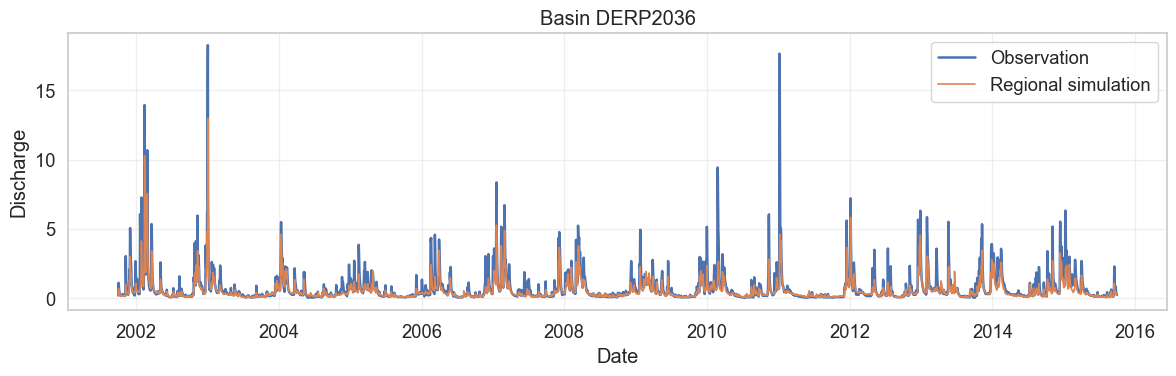

0.7106360197067261


In [740]:
df = basin_timeseries_df(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)

plot_timeseries(
    ds,
    basin_id="DERP2036",
    start="2001-01-01",
    end="2015-12-31",
)
print(compute_nse(df.obs, df.sim, expo=1))

In [ ]:
df_sig = basin_timeseries_df(
    ds,
    basin_id="DERP2033",
    start=SIG_START,
    end=SIG_END,
)

nse_df = compute_nse(df_sig.obs.values, df_sig.sim.values, expo=1)
nse_df

0.8271479606628418

In [695]:
compute_nse(df.obs, df.sim, expo=1)

0.8271479606628418

In [485]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [691]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.746685,0.651427,0.446366,0.520332,123.076923,126.000000,3.762767,3.182752,1.080588,0.838242
DERP2006,0.753616,0.634109,0.440146,0.502926,121.230769,126.153846,3.796252,3.149219,1.416212,1.100160
DERP2007,0.776588,0.607807,0.498234,0.581583,126.461538,130.461538,2.828146,2.400644,1.074993,0.844751
DERP2008,0.716136,0.607938,0.473465,0.533966,121.923077,127.538462,3.486582,2.701300,0.964844,0.747735
DERP2010,0.756684,0.669506,0.574114,0.673324,133.000000,137.230769,1.981595,1.425972,0.905834,0.798632
DERP2011,0.805480,0.700705,0.558243,0.670483,131.076923,138.307692,1.954964,1.468473,0.767888,0.730952
DERP2013,0.640304,0.701034,0.815621,0.859069,161.846154,162.076923,0.931772,0.498695,0.677523,0.827247
DERP2017,0.855101,0.846378,0.625862,0.653996,134.846154,136.384615,2.678084,2.406283,1.222016,1.134906
DERP2018,0.869199,0.776267,0.583362,0.652045,134.076923,136.923077,2.708539,2.453381,0.973843,0.870554


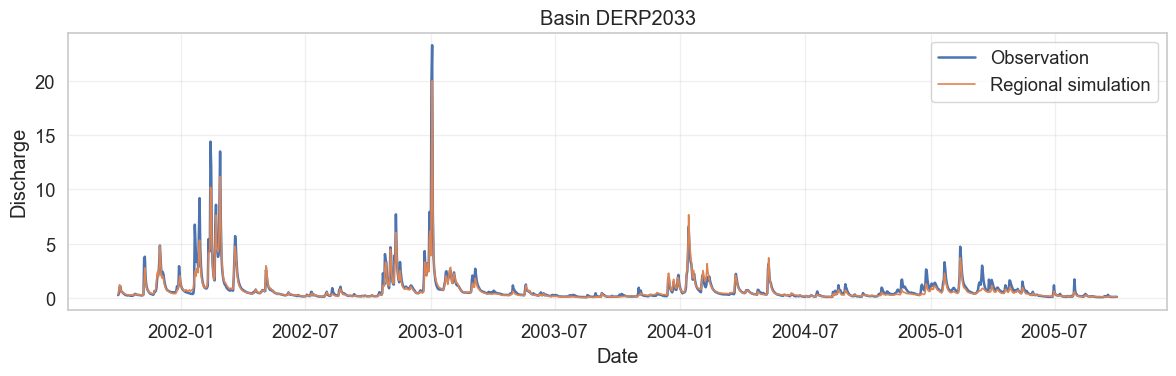

In [486]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [509]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.747557,0.631121,0.446366,0.531250,123.076923,124.846154,3.762767,3.240430,1.080588,0.834222
DERP2006,0.776796,0.707423,0.440146,0.492665,121.230769,123.076923,3.796252,3.257715,1.416212,1.179943
DERP2007,0.784713,0.641077,0.498234,0.560791,126.461538,128.000000,2.828146,2.527217,1.074993,0.851712
DERP2008,0.723418,0.613024,0.473465,0.557048,121.923077,125.923077,3.486582,2.705579,0.964844,0.773069
DERP2010,0.761919,0.703639,0.574114,0.675443,133.000000,136.923077,1.981595,1.625394,0.905834,0.839271
DERP2011,0.800979,0.713536,0.558243,0.668784,131.076923,136.769231,1.954964,1.533157,0.767888,0.745337
DERP2013,0.637653,0.726163,0.815621,0.849111,161.846154,160.769231,0.931772,0.606774,0.677523,0.822726
DERP2017,0.857811,0.868379,0.625862,0.632463,134.846154,132.615385,2.678084,2.492056,1.222016,1.119393
DERP2018,0.886020,0.835166,0.583362,0.633829,134.076923,134.384615,2.708539,2.821260,0.973843,0.899349


In [508]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.773258,0.755627,0.673537,0.808375,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.678210,0.794565,0.753409
DEB10340,0.914429,0.872219,0.863366,0.838175,0.466658,0.543620,0.476221,130.153846,131.923077,129.923077,3.492968,2.673907,3.163043,0.709773,0.708054,0.738183
DEB10900,0.863517,0.742275,0.761490,0.679681,0.446361,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.082247,0.917633,0.847428
DEB10910,0.856918,0.685117,0.762683,0.732293,0.439976,0.478172,0.491285,121.230769,122.923077,126.000000,3.648402,3.362612,2.813519,1.430583,1.123399,1.293489
DEB10940,0.840432,0.641799,0.784728,0.655410,0.498208,0.558440,0.633380,126.461538,129.307692,130.846154,2.862005,2.755667,1.485474,1.074739,0.847113,0.928117
DEB10950,0.818772,0.659826,0.733318,0.645252,0.473617,0.481811,0.534007,121.923077,121.615385,121.769231,3.447979,3.718878,2.998221,0.961400,0.736088,0.824843
DEB10970,0.892492,0.815111,0.779993,0.751681,0.573982,0.608946,0.603998,133.076923,137.307692,144.846154,1.981595,1.822970,1.931111,0.908467,0.858445,0.878783
DEB10980,0.901377,0.786033,0.810827,0.744425,0.558289,0.617852,0.636968,131.076923,135.769231,136.153846,1.954963,2.193693,1.843175,0.769578,0.729296,0.798201
DEB11010,0.899306,0.898982,0.842688,0.898910,0.626141,0.640879,0.633918,134.769231,136.230769,131.538462,2.703024,2.550204,2.355243,1.226270,1.180808,1.220119


In [505]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.878109,0.796404,0.796856,0.781507,0.559014,0.598989,0.583162,132.860577,134.663462,134.091346,2.609873,2.490069,2.418110,0.948340,0.882632,0.903174
std,0.042016,0.089368,0.052731,0.079255,0.091058,0.090617,0.093714,9.475442,9.966566,11.154331,0.755559,0.709012,0.712292,0.206180,0.153279,0.171173
min,0.773258,0.641799,0.673537,0.645252,0.439976,0.478172,0.469600,121.230769,121.615385,118.307692,0.931772,0.638075,0.845974,0.678210,0.707694,0.684354
25%,0.861867,0.737114,0.762384,0.741392,0.492060,0.549944,0.523326,129.173077,130.288462,129.134615,2.070733,2.162768,1.990265,0.767020,0.734390,0.787003
50%,0.886489,0.800572,0.801501,0.779285,0.570401,0.601271,0.581235,132.192308,135.076923,132.769231,2.702418,2.584174,2.410614,0.968049,0.856293,0.863106
75%,0.904640,0.867526,0.837172,0.837813,0.596515,0.627967,0.630484,134.769231,136.903846,136.923077,3.008498,2.797872,2.859695,1.065473,0.969460,0.973455
max,0.928655,0.927112,0.872537,0.909854,0.815618,0.861286,0.849576,161.846154,165.692308,167.846154,3.762767,3.718878,3.675826,1.430583,1.180808,1.293489


In [506]:
df_seed_metrics_and_signatures.describe()

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.793356,0.732878,0.559018,0.620252,132.860577,134.125000,2.622836,2.268689,0.946392,0.844602
std,0.068167,0.095672,0.091021,0.081998,9.476399,8.471829,0.769685,0.714872,0.203778,0.161623
min,0.637653,0.577742,0.440146,0.492665,121.230769,123.076923,0.931772,0.606774,0.677523,0.524933
25%,0.750068,0.687998,0.492042,0.559855,129.173077,130.423077,2.073547,1.716882,0.765782,0.766136
50%,0.786164,0.724668,0.570509,0.633146,132.153846,134.500000,2.693311,2.509637,0.969344,0.836746
75%,0.849145,0.783959,0.596518,0.652119,134.788462,136.423077,2.992755,2.719969,1.063192,0.911433
max,0.886020,0.932236,0.815621,0.849111,161.846154,160.769231,3.796252,3.257715,1.416212,1.179943


In [490]:
df_metrics_and_signatures.describe()

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.910888,0.839808,0.840049,0.833418,0.562374,0.593446,0.579115,124.729167,125.166667,127.750000,2.495764,2.626160,2.480959,0.975998,0.944586,1.000333
std,0.035819,0.057070,0.058223,0.055875,0.091693,0.089610,0.093098,8.648887,10.271139,10.093269,0.788332,0.741073,0.739886,0.198569,0.181528,0.226275
min,0.835367,0.724381,0.734747,0.738516,0.441753,0.481512,0.468662,114.333333,113.666667,118.000000,0.773778,0.638075,0.965011,0.722457,0.711417,0.760322
25%,0.889832,0.811855,0.794056,0.793547,0.499283,0.541187,0.513934,120.333333,120.166667,121.250000,1.958305,2.270540,2.079689,0.814437,0.803664,0.833364
50%,0.916679,0.832932,0.855280,0.841802,0.579749,0.590523,0.585210,123.833333,123.000000,124.000000,2.690372,2.694704,2.549561,0.972156,0.934422,0.942745
75%,0.940056,0.872592,0.878509,0.868134,0.587945,0.624725,0.628832,125.166667,126.583333,130.666667,2.815167,2.875483,2.897589,1.074568,1.012772,1.091463
max,0.960303,0.937298,0.922789,0.923746,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,3.832113,3.843974,4.200892,1.474606,1.319979,1.570151


In [491]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.868938,0.803746,0.787528,0.883045,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,0.773778,0.638075,0.965011,0.746414,0.803915,0.760322
DEB10340,0.936365,0.872293,0.875587,0.819804,0.458994,0.541745,0.481878,117.666667,123.000000,122.333333,3.220891,2.802875,2.929827,0.722457,0.711417,0.761294
DEB10900,0.919011,0.832592,0.834323,0.819509,0.457812,0.515174,0.468662,120.333333,119.666667,121.000000,3.832113,3.403042,4.200892,1.056757,0.968138,0.924292
DEB10910,0.894296,0.823152,0.754040,0.852647,0.441753,0.481512,0.482532,114.333333,114.333333,118.333333,3.692641,3.600680,2.886844,1.474606,1.319979,1.570151
DEB10940,0.893315,0.724381,0.850111,0.771888,0.506526,0.546268,0.606724,120.333333,119.000000,121.333333,2.792974,2.972210,1.583399,1.147987,0.961417,1.072930
DEB10950,0.835367,0.747280,0.773630,0.752155,0.477553,0.486041,0.527265,117.333333,113.666667,118.000000,2.755668,3.843974,3.036824,0.958193,0.806427,0.910034
DEB10970,0.894733,0.808425,0.804038,0.839166,0.582088,0.603661,0.588899,123.333333,126.333333,136.333333,2.100446,1.914479,2.100446,0.992535,0.930513,1.022991
DEB10980,0.926470,0.833271,0.860449,0.772878,0.571602,0.612856,0.637778,121.333333,123.666667,128.000000,1.760696,2.414982,1.795466,0.794305,0.787892,0.891588
DEB11010,0.960303,0.926329,0.915261,0.880248,0.617668,0.630695,0.636038,124.333333,123.000000,123.000000,2.750172,2.627577,2.498434,1.205299,1.284620,1.341608


In [647]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.746685,0.651427,0.446366,0.520332,123.076923,126.000000,3.762767,3.182752,1.080588,0.838242
DERP2006,0.753616,0.634109,0.440146,0.502926,121.230769,126.153846,3.796252,3.149219,1.416212,1.100160
DERP2007,0.776588,0.607807,0.498234,0.581583,126.461538,130.461538,2.828146,2.400644,1.074993,0.844751
DERP2008,0.716136,0.607938,0.473465,0.533966,121.923077,127.538462,3.486582,2.701300,0.964844,0.747735
DERP2010,0.756684,0.669506,0.574114,0.673324,133.000000,137.230769,1.981595,1.425972,0.905834,0.798632
DERP2011,0.805480,0.700705,0.558243,0.670483,131.076923,138.307692,1.954964,1.468473,0.767888,0.730952
DERP2013,0.640304,0.701034,0.815621,0.859069,161.846154,162.076923,0.931772,0.498695,0.677523,0.827247
DERP2017,0.855101,0.846378,0.625862,0.653996,134.846154,136.384615,2.678084,2.406283,1.222016,1.134906
DERP2018,0.869199,0.776267,0.583362,0.652045,134.076923,136.923077,2.708539,2.453381,0.973843,0.870554


In [650]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()].describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,...,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,0.800599,0.796069,0.793245,0.784624,0.779142,0.712632,0.717761,0.709021,0.691288,0.684825,...,2.232791,2.240614,2.180610,2.213953,0.946392,0.807486,0.808831,0.812374,0.818682,0.823823
std,0.066530,0.071047,0.063413,0.064633,0.066438,0.093265,0.095724,0.090381,0.086075,0.080991,...,0.769987,0.713329,0.689973,0.729768,0.203778,0.157013,0.164348,0.161260,0.156179,0.163123
min,0.675041,0.629455,0.678560,0.661702,0.630111,0.573076,0.568915,0.561991,0.567047,0.543583,...,0.472823,0.486810,0.479410,0.518876,0.677523,0.528566,0.530064,0.527561,0.540625,0.533682
25%,0.759626,0.756873,0.752015,0.741238,0.740550,0.648789,0.653475,0.650402,0.629724,0.636415,...,1.666924,1.792321,1.708095,1.763239,0.765782,0.721317,0.704850,0.712643,0.722011,0.719690
50%,0.787565,0.790223,0.787202,0.781259,0.776944,0.711943,0.718524,0.706606,0.675398,0.683567,...,2.392464,2.534381,2.453792,2.380401,0.969344,0.815533,0.803369,0.811213,0.812997,0.828202
75%,0.860418,0.861520,0.848553,0.838681,0.831465,0.753873,0.758511,0.749104,0.724155,0.707537,...,2.773108,2.714357,2.603453,2.554843,1.063192,0.856285,0.864368,0.874992,0.889652,0.887008
max,0.898441,0.896161,0.891918,0.886177,0.879988,0.894840,0.909496,0.881633,0.865398,0.851938,...,3.365488,3.198022,3.190540,3.478586,1.416212,1.121371,1.152881,1.130648,1.118072,1.134743


In [633]:
data_diff_timeval_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_r1comp", "kge_r1comp"]]

,nse_r1comp,kge_r1comp
DERP2013,0.630111,0.679145
DERP2036,0.725862,0.543583
DERP2005,0.741902,0.629080
DERP2006,0.748110,0.638860
DERP2007,0.775207,0.608307
DERP2008,0.704388,0.581768
DERP2010,0.750580,0.656926
DERP2011,0.794404,0.687988
DERP2017,0.847233,0.823119
DERP2018,0.858639,0.753934


In [492]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.868938,0.803746,0.787528,0.883045,0.825523,0.859103,0.844286,152.000000,157.666667,158.000000,0.773778,0.638075,0.965011,0.746414,0.803915,0.760322
DEB10340,0.936365,0.872293,0.875587,0.819804,0.458994,0.541745,0.481878,117.666667,123.000000,122.333333,3.220891,2.802875,2.929827,0.722457,0.711417,0.761294
DEB10900,0.919011,0.832592,0.834323,0.819509,0.457812,0.515174,0.468662,120.333333,119.666667,121.000000,3.832113,3.403042,4.200892,1.056757,0.968138,0.924292
DEB10910,0.894296,0.823152,0.754040,0.852647,0.441753,0.481512,0.482532,114.333333,114.333333,118.333333,3.692641,3.600680,2.886844,1.474606,1.319979,1.570151
DEB10940,0.893315,0.724381,0.850111,0.771888,0.506526,0.546268,0.606724,120.333333,119.000000,121.333333,2.792974,2.972210,1.583399,1.147987,0.961417,1.072930
DEB10950,0.835367,0.747280,0.773630,0.752155,0.477553,0.486041,0.527265,117.333333,113.666667,118.000000,2.755668,3.843974,3.036824,0.958193,0.806427,0.910034
DEB10970,0.894733,0.808425,0.804038,0.839166,0.582088,0.603661,0.588899,123.333333,126.333333,136.333333,2.100446,1.914479,2.100446,0.992535,0.930513,1.022991
DEB10980,0.926470,0.833271,0.860449,0.772878,0.571602,0.612856,0.637778,121.333333,123.666667,128.000000,1.760696,2.414982,1.795466,0.794305,0.787892,0.891588
DEB11010,0.960303,0.926329,0.915261,0.880248,0.617668,0.630695,0.636038,124.333333,123.000000,123.000000,2.750172,2.627577,2.498434,1.205299,1.284620,1.341608


In [634]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.741902,0.629080,0.446366,0.510062,123.076923,125.692308,3.762767,3.345059,1.080588,0.811757
DERP2006,0.748110,0.638860,0.440146,0.519702,121.230769,126.076923,3.796252,2.954273,1.416212,1.121371
DERP2007,0.775207,0.608307,0.498234,0.573499,126.461538,129.692308,2.828146,2.373622,1.074993,0.833573
DERP2008,0.704388,0.581768,0.473465,0.531190,121.923077,127.769231,3.486582,2.664826,0.964844,0.724699
DERP2010,0.750580,0.656926,0.574114,0.674323,133.000000,137.692308,1.981595,1.460046,0.905834,0.784359
DERP2011,0.794404,0.687988,0.558243,0.667924,131.076923,137.923077,1.954964,1.518163,0.767888,0.711170
DERP2013,0.630111,0.679145,0.815621,0.863340,161.846154,163.076923,0.931772,0.489210,0.677523,0.819310
DERP2017,0.847233,0.823119,0.625862,0.648016,134.846154,136.230769,2.678084,2.334784,1.222016,1.103406
DERP2018,0.858639,0.753934,0.583362,0.641156,134.076923,136.384615,2.708539,2.498057,0.973843,0.843564


In [635]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.772249,0.755404,0.672616,0.808008,0.815621,0.861286,0.849576,161.846154,165.692308,167.846154,0.931772,0.638075,0.845974,0.677523,0.794565,0.753409
DEB10340,0.914734,0.874006,0.863557,0.839217,0.466863,0.543620,0.476221,130.153846,131.923077,129.923077,3.492967,2.673907,3.163043,0.708328,0.708054,0.738183
DEB10900,0.864061,0.743901,0.761965,0.681206,0.446366,0.512913,0.469600,123.076923,125.230769,118.307692,3.762767,3.104558,3.675826,1.080588,0.917633,0.847428
DEB10910,0.861057,0.696252,0.764915,0.742073,0.440146,0.478172,0.491285,121.230769,122.923077,126.000000,3.796252,3.362612,2.813519,1.416212,1.123399,1.293489
DEB10940,0.840351,0.641590,0.784670,0.655224,0.498234,0.558440,0.633380,126.461538,129.307692,130.846154,2.828146,2.755667,1.485474,1.074993,0.847113,0.928117
DEB10950,0.817335,0.655990,0.732070,0.641842,0.473465,0.481811,0.534007,121.923077,121.615385,121.769231,3.486582,3.718878,2.998221,0.964844,0.736088,0.824843
DEB10970,0.893220,0.818179,0.780517,0.754065,0.574114,0.608946,0.603998,133.000000,137.307692,144.846154,1.981595,1.822970,1.931111,0.905834,0.858445,0.878783
DEB10980,0.902080,0.788136,0.811273,0.745580,0.558243,0.617852,0.636968,131.076923,135.769231,136.153846,1.954964,2.193693,1.843175,0.767888,0.729296,0.798201
DEB11010,0.899664,0.902444,0.842581,0.900734,0.625862,0.640879,0.633918,134.846154,136.230769,131.538462,2.678084,2.550204,2.355243,1.222016,1.180808,1.220119


In [247]:
df_metrics_and_signatures

,NSE_lstm,KGE_lstm,NSE_hbv,KGE_hbv,bfi_obs,bfi_lstm,bfi_hbv,hfd_obs,hfd_lstm,hfd_hbv,slope_obs,slope_lstm,slope_hbv,qmean_obs,qmean_lstm,qmean_hbv
basin_id,,,,,,,,,,,,,,,,
DEB10130,0.689185,0.736200,0.577875,0.772595,0.818652,0.867098,0.857723,164.454545,168.636364,171.818182,0.918746,0.560371,0.778925,0.638321,0.772108,0.722343
DEB10340,0.900442,0.871933,0.847735,0.838082,0.478156,0.554747,0.484661,133.000000,134.909091,132.454545,3.492968,2.673907,3.044192,0.679128,0.685350,0.711040
DEB10900,0.841323,0.706702,0.725953,0.610691,0.449680,0.521042,0.480502,124.818182,127.363636,119.363636,3.762767,3.025845,3.634597,1.058245,0.874880,0.790735
DEB10910,0.835392,0.626713,0.756759,0.625956,0.443083,0.486817,0.506143,123.636364,125.636364,128.454545,3.648402,3.398002,2.739304,1.392268,1.047520,1.192932
DEB10940,0.809535,0.598276,0.743332,0.582510,0.504481,0.572073,0.658249,128.727273,132.181818,133.909091,2.881746,2.670301,1.369652,1.022487,0.784522,0.856861
DEB10950,0.812645,0.622604,0.713046,0.590061,0.482548,0.488987,0.548781,123.363636,123.090909,123.272727,3.486582,3.612540,2.816776,0.926112,0.680413,0.768072
DEB10970,0.892954,0.825996,0.759311,0.680222,0.577399,0.619574,0.621022,135.818182,141.454545,149.818182,1.975036,1.781172,1.923185,0.855508,0.818590,0.810979
DEB10980,0.887958,0.765350,0.777313,0.706730,0.563850,0.629774,0.647907,133.909091,139.454545,139.363636,2.049515,2.196654,1.836775,0.727746,0.687725,0.748665
DEB11010,0.871893,0.848305,0.805074,0.855195,0.636240,0.652677,0.643046,138.181818,139.909091,134.545455,2.627577,2.443866,2.281028,1.179085,1.113546,1.149450


In [345]:
df_seed_metrics_and_signatures

,NSE,KGE,bfi_obs,bfi_sim,hfd_obs,hfd_sim,slope_obs,slope_sim,qmean_obs,qmean_sim
basin_id,,,,,,,,,,
DERP2005,0.809075,0.593560,0.446366,0.511828,123.076923,126.076923,3.762767,3.410101,1.080588,0.787949
DERP2006,0.840208,0.659015,0.440146,0.494179,121.230769,123.538462,3.796252,3.180885,1.416212,1.118559
DERP2007,0.850053,0.613940,0.498234,0.577461,126.461538,128.769231,2.828146,2.448308,1.074993,0.843178
DERP2008,0.820136,0.582881,0.473465,0.533681,121.923077,127.230769,3.486582,2.790845,0.964844,0.734072
DERP2010,0.856514,0.704093,0.574114,0.659025,133.000000,138.461538,1.981595,1.646700,0.905834,0.823284
DERP2011,0.868366,0.716608,0.558243,0.656398,131.076923,137.461538,1.954964,1.711798,0.767888,0.738702
DERP2013,0.486360,0.686698,0.815621,0.861818,161.846154,163.538462,0.931772,0.463404,0.677523,0.818611
DERP2017,0.897640,0.838977,0.625862,0.623872,134.846154,134.076923,2.678084,2.511387,1.222016,1.081224
DERP2018,0.917598,0.796644,0.583362,0.630836,134.076923,134.769231,2.708539,2.569787,0.973843,0.864819


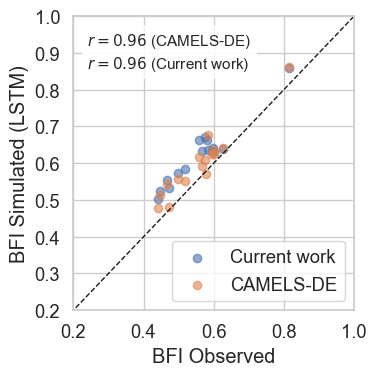

In [504]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = df_metrics_and_signatures
df2 = data_diff_timeval_complete_dict_plot.loc[
    exact_matches.estreams_id.tolist()
]

# ------------------------------------------------------------
# Extract data and drop NaNs (CRITICAL)
# ------------------------------------------------------------

x1 = df["bfi_obs"]
y1 = df["bfi_lstm"]
mask1 = (~x1.isna()) & (~y1.isna())
x1, y1 = x1[mask1], y1[mask1]

x2 = df2["bfi_obs"]
y2 = df2["bfi_r1comp"]
mask2 = (~x2.isna()) & (~y2.isna())
x2, y2 = x2[mask2], y2[mask2]

x3 = df2["bfi_obs"]
y3 = df2["bfi_nogeo"]
mask3 = (~x3.isna()) & (~y3.isna())
x3, y3 = x3[mask3], y3[mask3]

# Pearson correlations
r1, p1 = pearsonr(x1, y1)
r2, p2 = pearsonr(x2, y2)
r3, p3 = pearsonr(x3, y3)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(4, 4))
plt.scatter(x2, y2, alpha=0.6)
plt.scatter(x1, y1, alpha=0.6)
#plt.scatter(x3, y3, alpha=0.6)

# 1:1 line
lims = [0, 1]
plt.plot(lims, lims, "k--", linewidth=1)

plt.xlabel("BFI Observed")
plt.ylabel("BFI Simulated (LSTM)")
plt.xlim(0.2, 1)
plt.ylim(0.2, 1)
plt.grid(True)

# ------------------------------------------------------------
# Add Pearson r annotations
# ------------------------------------------------------------

plt.text(
    0.05, 0.95,
    rf"$r = {r1:.2f}$ (CAMELS-DE)",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

plt.text(
    0.05, 0.87,
    rf"$r = {r2:.2f}$ (Current work)",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

plt.legend(["Current work", "CAMELS-DE"])
plt.tight_layout()
plt.savefig("../results/figs/figures/SX_comparisonCAMELS.png", dpi=300)
# plt.show()


In [494]:
data_diff_val_complete_dict_plot_nse.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,124.000000,124.000000,124.000000,124.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.701148,0.702314,0.682569,0.693119,0.714618,0.632917,0.633455,0.625419,0.641115,0.660204,...,2.346902,2.282302,2.681072,2.643056,1.097993,0.993277,0.982460,0.970804,0.976053,0.958917
std,0.203131,0.213865,0.311369,0.398628,0.259607,0.167555,0.157196,0.178849,0.168671,0.153624,...,1.191962,0.889878,4.279453,4.327611,0.567213,0.555403,0.533969,0.541277,0.545191,0.542277
min,-0.422664,-0.798170,-2.010504,-3.517215,-1.712207,-0.016561,0.020369,-0.107608,-0.354413,-0.054540,...,0.734685,0.690832,0.994655,1.053290,0.264454,0.181575,0.146222,0.188042,0.117373,0.194840
25%,0.662419,0.667403,0.664224,0.678989,0.688546,0.548924,0.553947,0.549818,0.576363,0.571492,...,1.874028,1.870645,1.804532,1.768710,0.782773,0.656859,0.670301,0.645819,0.657241,0.627968
50%,0.746795,0.748087,0.740927,0.751744,0.760719,0.666852,0.634310,0.654642,0.668867,0.678773,...,2.201279,2.107406,2.099847,2.127353,0.962306,0.820589,0.851755,0.842559,0.825860,0.819690
75%,0.815519,0.813974,0.815831,0.815683,0.829164,0.736227,0.768067,0.746018,0.750381,0.766316,...,2.537435,2.505111,2.473696,2.626224,1.236292,1.127157,1.095467,1.093064,1.091162,1.061482
max,0.909402,0.906553,0.908585,0.904773,0.905084,0.919359,0.911352,0.915162,0.929735,0.908611,...,11.386008,7.669191,46.197067,49.513023,3.618939,3.315327,3.150639,3.209339,3.369995,3.663948


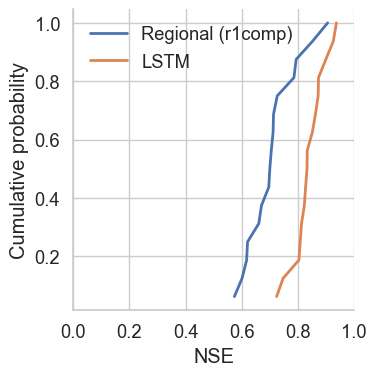

In [495]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data and drop NaNs
nse_r1comp = (
    data_diff_timeval_complete_dict_plot
    .loc[exact_matches.estreams_id.tolist(), "kge_r1comp"]
    .dropna()
    .values
)

nse_lstm = (
    df_metrics_and_signatures["KGE_lstm"]
    .dropna()
    .values
)

# Sort values
nse_r1comp_sorted = np.sort(nse_r1comp)
nse_lstm_sorted = np.sort(nse_lstm)

# Empirical CDF
cdf_r1comp = np.arange(1, len(nse_r1comp_sorted) + 1) / len(nse_r1comp_sorted)
cdf_lstm = np.arange(1, len(nse_lstm_sorted) + 1) / len(nse_lstm_sorted)

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    nse_r1comp_sorted,
    cdf_r1comp,
    label="Regional (r1comp)",
    linewidth=2
)

ax.plot(
    nse_lstm_sorted,
    cdf_lstm,
    label="LSTM",
    linewidth=2
)

ax.set_xlabel("NSE")
ax.set_ylabel("Cumulative probability")

ax.legend(frameon=False)
ax.set_xlim(0,1)
# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


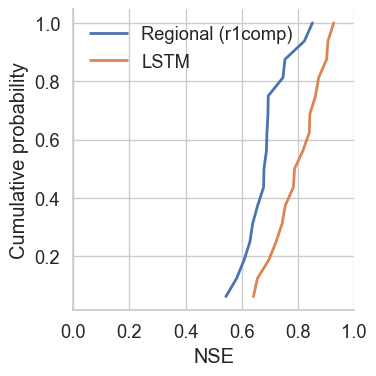

In [639]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data and drop NaNs
nse_r1comp = (
    data_diff_timeval_complete_dict_plot
    .loc[exact_matches.estreams_id.tolist(), "kge_r1comp"]
    .dropna()
    .values
)

nse_lstm = (
    df_metrics_and_signatures["KGE_lstm"]
    .dropna()
    .values
)

# Sort values
nse_r1comp_sorted = np.sort(nse_r1comp)
nse_lstm_sorted = np.sort(nse_lstm)

# Empirical CDF
cdf_r1comp = np.arange(1, len(nse_r1comp_sorted) + 1) / len(nse_r1comp_sorted)
cdf_lstm = np.arange(1, len(nse_lstm_sorted) + 1) / len(nse_lstm_sorted)

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    nse_r1comp_sorted,
    cdf_r1comp,
    label="Regional (r1comp)",
    linewidth=2
)

ax.plot(
    nse_lstm_sorted,
    cdf_lstm,
    label="LSTM",
    linewidth=2
)

ax.set_xlabel("NSE")
ax.set_ylabel("Cumulative probability")

ax.legend(frameon=False)
ax.set_xlim(0,1)
# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


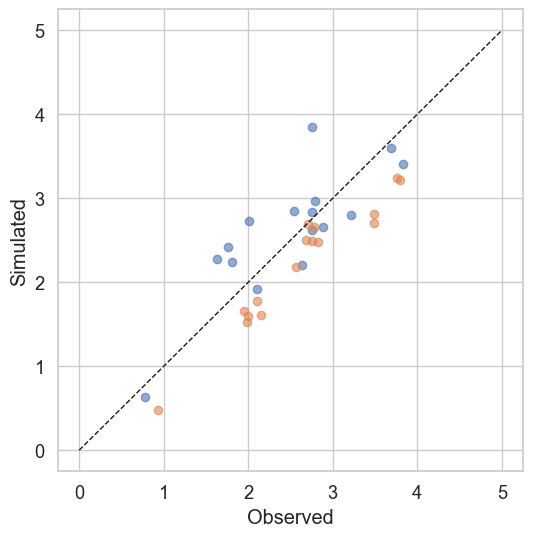

In [496]:
df = df_metrics_and_signatures
df2 = data_diff_timeval_complete_dict_plot.loc[
    exact_matches.estreams_id.tolist()]

plt.figure(figsize=(6, 6))
plt.scatter(df["slope_obs"], df["slope_lstm"], alpha=0.6)
plt.scatter(df2["slope_obs"], df2["slope_r1comp"], alpha=0.6)

# 1:1 line
lims = [0,5]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Observed")
plt.ylabel("Simulated")
plt.grid(True)
plt.show()


In [86]:
data_diff_val_complete_dict_plot.loc[exact_matches.estreams_id.tolist()][["nse_nogeo", "nse_r1comp", "bfi_obs", "bfi_r1comp", "bfi_nogeo"]]

,nse_nogeo,nse_r1comp,bfi_obs,bfi_r1comp,bfi_nogeo
DERP2013,0.579722,0.544453,0.815621,0.860716,0.852098
DERP2036,0.801759,0.835257,0.466863,0.571751,0.613097
DERP2005,0.799174,0.796452,0.446366,0.510476,0.519360
DERP2006,0.821049,0.821781,0.440146,0.485001,0.499168
DERP2007,0.827341,0.824661,0.498234,0.568604,0.583552
DERP2008,0.775513,0.821603,0.473465,0.525055,0.521355
DERP2010,0.842391,0.859205,0.574114,0.656742,0.645232
DERP2011,0.863369,0.871503,0.558243,0.650300,0.646389
DERP2017,0.900380,0.893593,0.625862,0.638772,0.624692
DERP2018,0.908871,0.926198,0.583362,0.635943,0.646819


In [91]:
df_metrics_and_signatures[["NSE_lstm", "bfi_obs", "bfi_lstm"]]

,NSE_lstm,bfi_obs,bfi_lstm
basin_id,,,
DEB10130,0.751104,0.815618,0.861286
DEB10340,0.902305,0.466658,0.543620
DEB10900,0.891866,0.446361,0.512913
DEB10910,0.896680,0.439976,0.478172
DEB10940,0.891963,0.498208,0.558440
DEB10950,0.870942,0.473617,0.481817
DEB10970,0.925893,0.573982,0.608946
DEB10980,0.910317,0.558289,0.617852
DEB11010,0.937411,0.626141,0.640879


In [141]:
data_diff_val_complete_dict_plot_garonne = data_diff_val_complete_dict_plot.loc[is_garonne, :]
data_diff_val_complete_dict_plot_moselle = data_diff_val_complete_dict_plot.loc[is_moselle, :]



In [394]:
data_diff_val_complete_dict_plot_garonne

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
FR004136,0.791797,0.807163,0.657238,0.812207,0.800962,0.833702,0.842162,0.628059,0.859150,0.776798,...,2.684104,2.340512,2.734999,3.153616,2.128744,1.923049,2.077411,2.873023,2.332196,1.967844
FR001547,0.744528,0.829095,0.802128,0.766157,0.786226,0.388884,0.690704,0.573368,0.541564,0.476634,...,3.260429,3.307054,1.896857,4.545642,0.829748,0.577587,0.563852,0.596910,0.578856,0.689708
FR004091,0.498752,0.078659,0.441742,0.591021,0.533380,0.352658,0.071063,0.337805,0.418099,0.375965,...,1.816803,2.299248,1.911117,0.980054,2.520212,1.512781,1.621199,1.430649,1.506093,1.121855
FR001592,0.660035,0.672577,0.649436,0.627409,0.681817,0.218846,0.676603,0.281791,0.168883,0.288811,...,4.892544,1.782664,3.197392,5.935422,0.262104,0.172997,0.136424,0.207094,0.164318,0.254936
FR001577,0.814510,0.824497,0.880036,0.837437,0.874655,0.628535,0.652963,0.755806,0.723154,0.738765,...,2.966282,3.599592,2.774088,2.719373,0.967203,0.984683,1.028054,0.990107,0.959758,0.988819
FR004140,0.800633,0.802957,0.762297,0.738847,0.814761,0.618791,0.766581,0.593938,0.597810,0.654082,...,7.129322,4.913071,8.721498,8.197469,0.476253,0.384923,0.339049,0.362991,0.375685,0.403597
FR004149,0.720816,0.643157,0.709187,0.723942,0.745599,0.676866,0.603184,0.673827,0.651396,0.709635,...,2.696735,2.781379,2.483379,2.305314,0.387913,0.449098,0.439597,0.486085,0.453478,0.520118
FR004152,0.570569,0.455332,0.701349,0.757802,0.706070,0.496417,0.393473,0.581141,0.556632,0.606900,...,2.471988,2.153756,1.538527,1.115842,0.352931,0.413445,0.353026,0.388430,0.433310,0.451860
FR001593,0.692235,0.625901,0.715299,0.630010,0.608680,0.610390,0.675380,0.553044,0.595308,0.512112,...,2.694466,2.232085,1.613524,2.999631,0.293235,0.215031,0.336532,0.289153,0.308049,0.354833
FR001545,0.615607,0.766737,0.708483,0.559253,0.718436,0.431409,0.580653,0.515673,0.381859,0.513653,...,1.663107,1.913997,1.811726,2.077106,2.281194,1.647936,1.394502,1.625200,1.461554,1.715387


In [395]:
data_diff_val_complete_dict_plot_garonne["root_dep_mean"] = network_estreams_garonne_22_gauges["root_dep_mean"]

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_43714/4129171625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_diff_val_complete_dict_plot_garonne["root_dep_mean"] = network_estreams_garonne_22_gauges["root_dep_mean"]


In [397]:
data_diff_val_complete_dict_plot_garonne.corr()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran,root_dep_mean
nse_nogeo,1.000000,0.804109,0.787706,0.801757,0.847566,0.679652,0.684581,0.693012,0.661526,0.609237,...,-0.041542,0.241987,0.248723,-0.160237,0.011825,0.038579,0.081421,0.048139,0.050624,0.335241
nse_ran,0.804109,1.000000,0.779432,0.519739,0.806172,0.440156,0.845827,0.476056,0.407862,0.476602,...,-0.244057,0.132495,0.261981,-0.064272,0.100758,0.074254,0.168422,0.117017,0.224454,0.189563
nse_g1comp,0.787706,0.779432,1.000000,0.653411,0.745821,0.485901,0.593414,0.659373,0.524036,0.483079,...,-0.296121,0.002628,-0.028860,-0.176547,-0.048797,-0.092144,-0.092612,-0.091883,-0.005582,0.251798
nse_c1comp,0.801757,0.519739,0.653411,1.000000,0.833932,0.658719,0.431537,0.732307,0.775713,0.677866,...,-0.063350,0.032562,-0.026283,-0.123202,0.080345,0.121750,0.127218,0.117438,0.064920,0.224254
nse_r1comp,0.847566,0.806172,0.745821,0.833932,1.000000,0.591307,0.654691,0.671846,0.644464,0.741482,...,-0.119527,0.169616,0.123647,-0.011413,0.210953,0.212117,0.244914,0.219746,0.256193,0.200249
kge_nogeo,0.679652,0.440156,0.485901,0.658719,0.591307,1.000000,0.581298,0.858509,0.937707,0.894952,...,-0.120680,0.086823,-0.078248,-0.005614,0.206162,0.266004,0.295559,0.278956,0.215263,0.172602
kge_ran,0.684581,0.845827,0.593414,0.431537,0.654691,0.581298,1.000000,0.498648,0.528597,0.585731,...,-0.235959,0.236446,0.412612,-0.146585,0.051142,0.078311,0.187561,0.124158,0.176281,0.305991
kge_g1comp,0.693012,0.476056,0.659373,0.732307,0.671846,0.858509,0.498648,1.000000,0.869566,0.813498,...,0.000688,-0.009192,-0.109366,-0.170973,0.015035,0.026570,0.015333,0.018180,0.010478,0.214551
kge_c1comp,0.661526,0.407862,0.524036,0.775713,0.644464,0.937707,0.528597,0.869566,1.000000,0.889982,...,-0.118580,-0.001326,-0.163861,0.038985,0.253518,0.312492,0.314091,0.308326,0.240612,0.129243
kge_r1comp,0.609237,0.476602,0.483079,0.677866,0.741482,0.894952,0.585731,0.813498,0.889982,1.000000,...,-0.162524,0.071344,-0.121959,0.075854,0.333645,0.391737,0.395978,0.389413,0.359598,0.130212


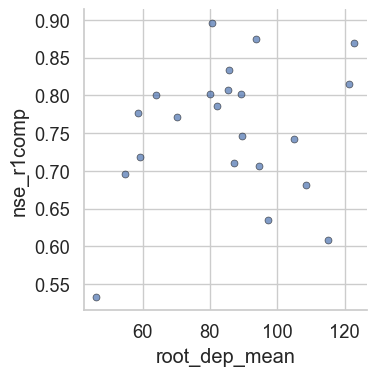

In [398]:
# Example variable names — CHANGE THESE
x_var = "root_dep_mean"
y_var = "nse_r1comp"

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    data_diff_val_complete_dict_plot_garonne[x_var],
    data_diff_val_complete_dict_plot_garonne[y_var],
    s=25,
    edgecolor="k",
    linewidth=0.5,
    alpha=0.7
)

ax.set_xlabel(x_var)
ax.set_ylabel(y_var)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [402]:
selected_ids = ["FR000144", "FR000185", "FR003250","FR003280"]


In [406]:
data_diff_val_complete_dict_plot_moselle.loc[selected_ids, ["nse_r1comp", "nse_nogeo"]]

,nse_r1comp,nse_nogeo
FR000144,-4.009779,0.003880
FR000185,-1.443874,-0.982576
FR003250,0.255330,0.226463
FR003280,0.050772,0.080444


In [407]:
data_diff_val_complete_dict_plot_moselle[data_diff_val_complete_dict_plot_moselle.nse_r1comp	<0.5
                                         ]

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
LU000010,0.139887,0.662677,-3.348094,0.058807,-0.087053,0.278436,0.450072,-1.356982,0.278591,0.172998,...,1.205862,2.332592,1.847120,1.812269,0.888896,1.607327,1.491281,2.758666,1.499753,0.662621
FR000185,-0.982576,-0.229102,-1.154297,-0.867087,-1.443874,-0.349765,0.108693,-0.431503,-0.267559,-0.557429,...,NaN,NaN,NaN,NaN,0.748184,1.896837,1.679766,1.796205,1.740608,1.367770
FR000144,0.003880,-0.008453,-0.128026,-0.839542,-4.009779,0.279814,0.258309,0.311356,0.233645,-0.591163,...,1.026024,1.163124,0.950036,1.004856,1.311974,3.227080,2.056430,1.306515,1.025588,1.252472
FR003280,0.080444,0.157396,0.054219,0.038718,0.050772,0.169549,0.245653,0.225547,0.160328,0.158208,...,1.917713,3.446404,2.268434,2.721692,1.277349,0.482898,0.483430,0.508274,0.495095,0.533497
FR000184,-0.440142,-0.540514,-1.340600,-0.741914,-0.676622,0.431829,0.439366,0.237163,0.323041,0.283304,...,1.533180,1.739807,2.254170,2.163336,1.283689,0.545375,0.549425,0.456770,0.627291,0.615484
FR003288,0.382173,0.529743,0.257762,0.317271,0.300956,0.426180,0.491950,0.383881,0.373550,0.363647,...,1.073867,1.585046,1.015839,1.116440,0.479704,0.693427,0.682050,0.746087,0.667003,0.587962
DERP2013,-0.585839,0.083252,-0.011517,0.164664,0.257138,-0.494676,-0.017771,0.147127,0.025818,0.254414,...,1.497385,1.730672,1.933928,1.434439,0.637697,0.601188,0.687546,0.615681,0.692921,0.671836
FR003250,0.226463,0.466944,0.333184,0.422748,0.255330,0.129208,0.318669,0.175846,0.262104,0.184632,...,1.960291,1.881206,1.816326,1.867556,2.183687,3.113163,2.933963,2.945627,3.154295,2.781069
FR003254,0.153975,0.458547,0.401982,0.529733,0.289045,0.338200,0.528674,0.531494,0.595055,0.476466,...,NaN,NaN,NaN,NaN,1.289084,1.925145,1.679488,1.867987,2.128503,1.880406


In [408]:
data_diff_val_complete_dict_plot_moselle.describe()

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,...,102.000000,102.000000,102.000000,102.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,0.724855,0.746739,0.685902,0.724073,0.698153,0.639785,0.659864,0.641171,0.643496,0.646912,...,2.220349,2.139361,2.142166,2.113391,1.088224,1.055521,1.037493,1.044167,1.026681,1.009124
std,0.298367,0.223761,0.511136,0.308179,0.549938,0.215726,0.173362,0.273423,0.193819,0.231923,...,0.755807,0.588751,0.594292,0.572280,0.541739,0.636134,0.572966,0.594945,0.606629,0.578118
min,-0.982576,-0.540514,-3.348094,-0.867087,-4.009779,-0.494676,-0.017771,-1.356982,-0.267559,-0.591163,...,0.632381,0.695410,0.950036,0.882601,0.446308,0.361161,0.377456,0.390437,0.366686,0.438161
25%,0.728419,0.731569,0.717265,0.729463,0.744047,0.572007,0.578388,0.572673,0.572789,0.581368,...,1.759924,1.787336,1.852481,1.778707,0.786971,0.699870,0.701428,0.706979,0.693448,0.671374
50%,0.810292,0.801497,0.810581,0.812167,0.822008,0.684554,0.676940,0.706665,0.695238,0.704259,...,2.147157,2.018779,2.082792,2.109403,0.949175,0.853998,0.863019,0.852875,0.838540,0.848954
75%,0.862117,0.865213,0.872231,0.874805,0.870385,0.781883,0.789478,0.799021,0.772006,0.778307,...,2.602936,2.410236,2.321558,2.316812,1.193828,1.115533,1.131235,1.096072,1.049442,1.086022
max,0.933677,0.937376,0.936008,0.940521,0.936531,0.925716,0.918646,0.922882,0.908377,0.912003,...,5.981355,4.023768,5.526507,4.614766,3.597879,3.714245,3.477162,3.702544,3.746849,3.884222


## Figures

In [61]:
moselle=gpd.read_file(path_data+"/gis/paper_moselle/gis/moselle_delienation.shp")
rivers_moselle=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/rivers_moselle.shp")
catchment_boundaries = gpd.read_file(path_data+'//EStreams/shapefiles/estreams_catchments.shp')
catchment_boundaries.set_index("basin_id", inplace=True)

rivers_garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/rivers_garonne.shp")

garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne.shp")

In [62]:
##################################################################################################################
# Global geology clipped to the Moselle catchment
GLiM_moselle = gpd.read_file(path_data+"/gis/paper_moselle//raster/glim_moselle_wgs.shp")

attribute_field = 'xx'
GLiM_moselle_dissolved = GLiM_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
GLiM_moselle_dissolved["class"] = GLiM_moselle_dissolved.index

# Define the permeability columns dictionary
permeability_columns_glim = {
    "very low": ['ev', 'ig', 'pa', 'pb', 'va', 'vb', "wb"],
    "low": ['mt', 'pi', 'py', 'vi'],
    "medium": ['sc', 'sm'],
    "high": ['su', 'ss']
}

# Create a new column for reclassified permeability
def reclassify_glim_class(class_name):
    for permeability, classes in permeability_columns_glim.items():
        if class_name in classes:
            return permeability
    return None

GLiM_moselle_dissolved['permeability'] = GLiM_moselle_dissolved['class'].apply(reclassify_glim_class)

##################################################################################################################
# Continental geology clipped to the Moselle catchment
geology_median_moselle = gpd.read_file(path_data+"/gis/paper_moselle//raster/geology_median_moselle_wgs.shp")

attribute_field = 'LEVEL3'
geology_median_moselle_dissolved = geology_median_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_median_moselle_dissolved["class"] = geology_median_moselle_dissolved.index

# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Conglomerates", "Conglomerates and sands", "Gravels", 
             "Sands", "Sandstones", "Sandstones and sands"],
    "medium": ["Conglomerates and clays", "Gneisses", "Limestones", 
               "Limestones and sands", "Sandstones and clays", "Sandstones and marls",
               "Limestones and clays", "Limestones and marls", "Marlstones and sands"],
    "low": ["Claystones and clays", "Marbles",
              "Marls", "Marlstones", "Marlstones and clays", 
              "Marlstones and marls", "Phyllites", "Schists",
              "Silts"],
    "very low": ["Plutonic rocks", "Volcanic rocks", 
                    "Inland water", "Snow field / ice field",
                    "Clays",  'Quartzites', "Shales"]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_median_moselle_dissolved['permeability'] = geology_median_moselle_dissolved['class'].apply(reclassify_geology_class)

##################################################################################################################
# Regional geology clipped to the Moselle catchment
geology_high_moselle = gpd.read_file(path_data+'/gis/lithology/moselle_hr_ff.shp')

attribute_field = 'Labels01'
geology_high_moselle_dissolved = geology_high_moselle.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_high_moselle_dissolved["class"] = geology_high_moselle_dissolved.index

# Set the CRS to WGS84
geology_high_moselle_dissolved = geology_high_moselle_dissolved.to_crs(epsg=4326)


# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Alluvium", 'Coal', 'Conglomerate', 'Gravel and sand',
             'Sand', 'Sand and gravel', 'Sandstone and conglomerate', 'Sandstone'
        ],
    
    "medium": ['Limestone', 'Sandstone and marl', 'Sandstone and schist',
              'Sandstone, conglomerate and marl'],
    
    "low": ['Arkose', 'Dolomite rock', 'Limestone and marl', 'Marl', 
             'Marl and dolomite', 'Marl and limestone', 'Marl and sandstone',
             'Sandstone and siltstone', 'Sandstone, siltstone and schist', 
              'Schist and sandstone', 'Silt',  'Silt and schist', 'Siltstone, sandstone and schist'
              ,"Siltstone"
             ],
    
    "very low": ['Cristallin basement', 'Plutonic rock',  'Quarzite',
                    'Schist','Volcanic rock' 
                   ]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_high_moselle_dissolved['permeability'] = geology_high_moselle_dissolved['class'].apply(reclassify_geology_class)

In [63]:
##################################################################################################################
# Global geology clipped to the Moselle catchment
GLiM_garonne = gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne_lr.shp")
attribute_field = 'xx'
GLiM_garonne_dissolved = GLiM_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
GLiM_garonne_dissolved["class"] = GLiM_garonne_dissolved.index

# Define the permeability columns dictionary
permeability_columns_glim = {
    "very low": ['ev', 'ig', 'pa', 'pb', 'va', 'vb', "wb"],
    "low": ['mt', 'pi', 'py', 'vi'],
    "medium": ['sc', 'sm'],
    "high": ['su', 'ss']
}

# Create a new column for reclassified permeability
def reclassify_glim_class(class_name):
    for permeability, classes in permeability_columns_glim.items():
        if class_name in classes:
            return permeability
    return None

GLiM_garonne_dissolved['permeability'] = GLiM_garonne_dissolved['class'].apply(reclassify_glim_class)

##################################################################################################################
# Continental geology clipped to the Moselle catchment
geology_median_garonne = gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/garonne_mr.shp")

attribute_field = 'LEVEL3'
geology_median_garonne_dissolved = geology_median_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_median_garonne_dissolved["class"] = geology_median_garonne_dissolved.index

# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": ["Conglomerates", "Conglomerates and sands", "Gravels", 
             "Sands", "Sandstones", "Sandstones and sands"],
    "medium": ["Conglomerates and clays", "Gneisses", "Limestones", 
               "Limestones and sands", "Sandstones and clays", "Sandstones and marls",
               "Limestones and clays", "Limestones and marls", "Marlstones and sands"],
    "low": ["Claystones and clays", "Marbles",
              "Marls", "Marlstones", "Marlstones and clays", 
              "Marlstones and marls", "Phyllites", "Schists",
              "Silts"],
    "very low": ["Plutonic rocks", "Volcanic rocks", 
                    "Inland water", "Snow field / ice field",
                    "Clays",  'Quartzites', "Shales"]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_median_garonne_dissolved['permeability'] = geology_median_garonne_dissolved['class'].apply(reclassify_geology_class)

##################################################################################################################
# Regional geology clipped to the Moselle catchment
geology_high_garonne = gpd.read_file(path_data+'/gis/paper_moselle_superflexpy/shps/garonne/garonne_hr_nodissol.shp')

attribute_field = 'class'
geology_high_garonne_dissolved = geology_high_garonne.dissolve(by=attribute_field)

# Now we create a new feature with the geology class:
geology_high_garonne_dissolved["class"] = geology_high_garonne_dissolved.index

# Set the CRS to WGS84
geology_high_garonne_dissolved = geology_high_garonne_dissolved.to_crs(epsg=4326)


# Define the permeability columns dictionary
permeability_columns_geology = {
    "high": [ "Alluvium",
             'Sand, gravel and pebbles'    
        ],
    
    "medium": ['Carbonate rocks', 
               'Limestones', 
               'Limestones, sandstones and gravels', 
               'Limestones, sandstones and marls', 
               'Molasses and clays',  
               'Sands and clays',
                'Sedimentary rocks',
               'Sediments mesosoics',
            'Schists, gneisses, granites', 
             ],
    
    "low": ['Impermeable', 
            'Inland water', 
            'Magmatic rocks', 
            'Massif', 
            'Plutonic rocks',
            'Shales',
            'Granitoids',
                   ]
}

# Create a new column for reclassified permeability
def reclassify_geology_class(class_name):
    for permeability, classes in permeability_columns_geology.items():
        if class_name in classes:
            return permeability
    return None

geology_high_garonne_dissolved['permeability'] = geology_high_garonne_dissolved['class'].apply(reclassify_geology_class)

In [64]:
network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]


In [65]:
from shapely.geometry import Point
from shapely.geometry import box

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/2889056111.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/2889056111.py:64: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_moselle_dissolved.plot(column='permeability', ax=ax1, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/2889056111.py:91: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_median_moselle_dissolved.plot(column='permeability', ax=ax2, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/2889056111.py:114: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_moselle_dissolved.plot(column='permeability', ax=ax3, legend=True,


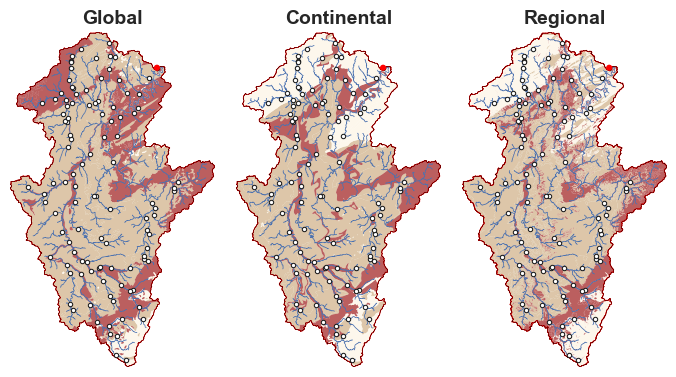

In [66]:
network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index
# Create the figure with two main columns: one for the first figure, one for the second figure (which will have 3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 4))  # Two subplots side by side

# Select multiple geometries
FR_selected_gdf = moselle.copy()

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_moselle_dissolved['color'] = GLiM_moselle_dissolved['permeability'].map(color_mapping_glim)
geology_median_moselle_dissolved['color'] = geology_median_moselle_dissolved['permeability'].map(color_mapping_geology)
geology_high_moselle_dissolved['color'] = geology_high_moselle_dissolved['permeability'].map(color_mapping_geology2)

# Set plot limits to the bounding box of the selected study areas
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]

# Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)

# Plot the first geology shapefile with different colors for each class
GLiM_moselle_dissolved.plot(column='permeability', ax=ax1, legend=True, 
                    categorical=True, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax1, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax1, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)

# Plot the mask to cover everything outside the study area
#mask.plot(ax=ax1, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# Set plot title and labels
ax1.set_xlabel('')
ax1.set_ylabel('')



# Plot the second geology shapefile with different colors for each class
geology_median_moselle_dissolved.plot(column='permeability', ax=ax2, legend=True, 
                    categorical=True, color=geology_median_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax2, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax2, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)
# Set plot limits to the bounding box of the study area
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# Set plot title and labels
#ax2.set_title('(c)', loc="left")
ax2.set_xlabel('')
ax2.set_ylabel('')
custom_label = ["Low", "Medium-low", "Medium-high", "High"]

# Plot the third geology shapefile with different colors for each class
geology_high_moselle_dissolved.plot(column='permeability', ax=ax3, legend=True, 
                    categorical=True, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax3, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax3, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["DEBU1959"]].plot(ax=ax3, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)


# Plot the river
rivers_moselle.plot(ax=ax1, linewidth=0.5, label='River network')
rivers_moselle.plot(ax=ax2, linewidth=0.5, label='River network')
rivers_moselle.plot(ax=ax3, linewidth=0.5, label='River network')

# Plot the mask to cover everything outside the study area
mask.plot(ax=ax3, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Set plot title and labels
#ax3.set_title('(d)', loc="left")

text_to_subplots = ["Global", "Continental", "Regional"]
i = 0 
for ax in [ax1, ax2, ax3]:

    # Overlay the study area boundaries
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, label='Sub-catchments')

    # Hide spines for main plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    # Add text below the plot
    #ax.text(0.45, 1.075, text_to_subplots[i], transform=ax.transAxes, 
    #        fontsize=10, ha='center', va='top', color='black', fontweight='bold')
    ax.set_title(text_to_subplots[i], loc="center", fontsize=14, fontweight="bold")
    i = i + 1

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.75),
    'Medium': to_rgba('tan', 0.75),
    'High': to_rgba('brown', 0.75)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
#legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
#                   bbox_to_anchor=(0.5, -0.01), ncol=5)
## Make the legend title bold
#legend.get_title().set_fontweight('bold')


# Adjust the layout to remove extra space
plt.tight_layout()


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/1802628556.py:92: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_moselle_dissolved.plot(column='permeability', ax=ax, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/1802628556.py:96: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_79388/1802628556.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


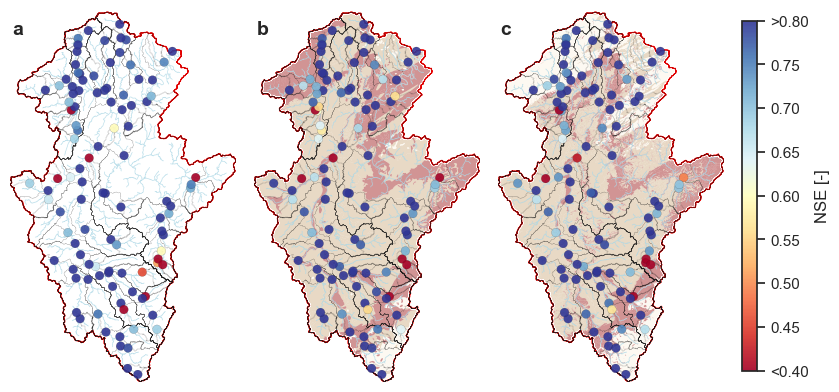

In [67]:
catchment_boundaries_moselle = catchment_boundaries.loc[network_estreams_gdf.index.tolist(), :]

selected_ids = ["FR000144", "FR000185", "FR003250","FR003280"]


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines
from shapely.geometry import box


network_estreams_gdf = network_estreams_moselle_108_gauges.loc[~network_estreams_moselle_108_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_moselle_dissolved['color'] = GLiM_moselle_dissolved['permeability'].map(color_mapping_glim)
geology_median_moselle_dissolved['color'] = geology_median_moselle_dissolved['permeability'].map(color_mapping_geology)
geology_high_moselle_dissolved['color'] = geology_high_moselle_dissolved['permeability'].map(color_mapping_geology2)

# Set style
sns.set_theme(style="ticks")

# Copy and add coordinates
df = data_diff_val_complete_dict_plot.copy()
df[["lat", "lon"]] = network_estreams_moselle_108_gauges[["lat", "lon"]]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(7.5, 5), sharex=True, sharey=True)

# NSE columns and titles
nse_cols = ['nse_nogeo', 'nse_g1comp', 'nse_r1comp']
titles = ['a', 'b', 'c']
main_titles = [r"$\mathbf{B_{\mathrm{ben}}}$", r"$\mathbf{B_{\mathrm{glo}}}$", 
                r"$\mathbf{B_{\mathrm{reg}}}$"]

background_maps = ['none', 'GLiM', 'high']

# Set plot limits to the bounding box of the selected study areas
FR_selected_gdf = moselle.copy()
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]+ 0.02

## Create a mask that covers the entire plotting area
#plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
#mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Color setup
vmin, vmax = 0.4, 0.8
cmap_nse = plt.cm.RdYlBu

# Plot loop
for ax, col, subtitle, maintitle, bg_type in zip(axes, nse_cols, titles, main_titles, background_maps):

    # Add background geology map where appropriate
    if bg_type == 'GLiM':
        GLiM_moselle_dissolved.plot(column='permeability', ax=ax, color=GLiM_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'median':
        geology_median_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_median_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'high':
        geology_high_moselle_dissolved.plot(column='permeability', ax=ax, color=geology_high_moselle_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)

    # Add rivers and boundary for all
    moselle.plot(ax=ax, color='none', linewidth=2, alpha=1)
    rivers_moselle.plot(ax=ax, color='lightblue', linewidth=0.5, alpha=0.75)

#   if bg_type != 'none':
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25)


    mask.plot(ax=ax, facecolor='white', edgecolor='red', linewidth=0.75)

    # Scatter NSE values
    sc = ax.scatter(
        df['lon'], df['lat'],
        c=df[col],
        cmap=cmap_nse,
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='k',
        linewidth=0.1,
        alpha=0.9,
        zorder=10000
    )

    # Subplot letter
    ax.text(0.01, 0.97, subtitle, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

    # Set plot limits to the bounding box of the study area
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Clean look
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_xlabel(maintitle, fontsize=14, fontweight='bold')
    ax.set_ylabel("")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


    catchment_boundaries_moselle.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=0.1, label='Sub-catchments')



# Colorbar setup
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('NSE [-]')
ticks = np.linspace(0.4, 0.8, num=9)
tick_labels = [f"<0.40"] + [f"{t:.2f}" for t in ticks[1:-1]] + [f">0.80"]
#cbar.set_ticks(ticks)
cbar.set_ticks(np.arange(vmin, vmax + 0.05, 0.05))

cbar.set_ticklabels(tick_labels)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.5),
    'Medium': to_rgba('tan', 0.5),
    'High': to_rgba('brown', 0.5)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label, linewidth=0.5)
                   for label, color in color_dict_legend.items()]

## Add the legend outside the plot area with minimal space
#legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
#                   bbox_to_anchor=(0.5, -0.01), ncol=5)
## Make the legend title bold
#legend.get_title().set_fontweight('bold')


#axes[0].text(7.38,48.7, "FR000185", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.2,48.38, "FR000144", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.35,48.15, "FR003250", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(5.7,49.28, "FR003280", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
# Save and show
plt.tight_layout()
# Save including everything (colorbar + legend)
plt.savefig(
    "../results/figs/figures/FigSX_geomapsa_lstm.png",
    dpi=300,
    bbox_inches='tight')


plt.show()

In [461]:
data_diff_val_complete_dict_plot_moselle

,nse_nogeo,nse_ran,nse_g1comp,nse_c1comp,nse_r1comp,kge_nogeo,kge_ran,kge_g1comp,kge_c1comp,kge_r1comp,...,slope_c1comp,slope_g1comp,slope_nogeo,slope_ran,qmean_obs,qmean_r1comp,qmean_c1comp,qmean_g1comp,qmean_nogeo,qmean_ran
LU000018,0.708004,0.645161,0.613311,0.564327,0.728759,0.519452,0.425042,0.556437,0.309184,0.573954,...,0.812070,2.956945,1.575416,1.495972,0.875516,0.771046,0.767733,0.671032,0.740483,0.628584
LU000010,-0.253810,0.531080,-0.141319,0.598281,0.182699,0.045395,0.377272,0.039598,0.584577,0.328865,...,1.222602,4.223004,1.987243,1.656020,0.905003,1.472660,1.096171,1.471469,1.709276,0.553534
LU000001,0.887131,0.794342,0.844241,0.891292,0.883199,0.796192,0.792088,0.723189,0.756901,0.805964,...,3.244158,3.184234,2.927708,5.261025,1.182612,0.985025,0.967843,0.950618,0.989606,0.951205
DERP2028,0.761699,0.811432,0.744347,0.789432,0.794572,0.622202,0.631550,0.660630,0.541673,0.555633,...,1.460397,2.494703,2.226240,1.695546,0.955301,0.758786,0.746694,0.730590,0.726114,0.744433
FR000183,0.513281,0.150104,0.616502,0.267067,0.081775,0.644688,0.561833,0.776562,0.649062,0.608901,...,3.206024,2.438878,2.461757,3.284795,1.099655,0.698047,0.742405,0.926833,0.790545,0.663257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,0.796881,0.826878,0.802622,0.821837,0.808305,0.515870,0.592797,0.518329,0.548724,0.524168,...,2.332885,2.308954,1.782600,1.914561,1.040731,0.774757,0.769958,0.727615,0.769210,0.858933
FR003271,0.787464,0.782418,0.821171,0.798304,0.821013,0.539043,0.580716,0.553413,0.543808,0.578753,...,2.248059,2.192323,2.637527,2.370765,0.624199,0.479710,0.447601,0.497038,0.441947,0.438349
FR003301,0.905110,0.896444,0.900515,0.908468,0.893708,0.721253,0.686253,0.709992,0.743164,0.710545,...,2.093468,1.845995,2.106055,2.003049,0.788065,0.662018,0.679025,0.702483,0.695920,0.667897
DERP2003,0.839509,0.851834,0.767786,0.895105,0.890449,0.569379,0.621412,0.472140,0.727987,0.781115,...,2.217808,1.297436,1.752440,1.797834,0.931310,0.788044,0.780283,0.741589,0.742219,0.745398


/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:64: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_garonne_dissolved.plot(column='permeability', ax=ax1, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:91: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_median_garonne_dissolved.plot(column='permeability', ax=ax2, legend=True,
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/2515196404.py:114: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_garonne_dissolved.plot(column='permeability', ax=ax3, legend=True,


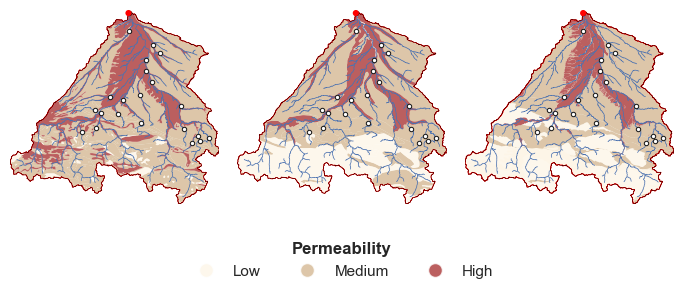

In [458]:
network_estreams_gdf = network_estreams_garonne_22_gauges.loc[~network_estreams_garonne_22_gauges.index.duplicated(keep='first')]

# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index
# Create the figure with two main columns: one for the first figure, one for the second figure (which will have 3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3))  # Two subplots side by side

# Select multiple geometries
FR_selected_gdf = garonne.copy()

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "oldlace",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_garonne_dissolved['color'] = GLiM_garonne_dissolved['permeability'].map(color_mapping_glim)
geology_median_garonne_dissolved['color'] = geology_median_garonne_dissolved['permeability'].map(color_mapping_geology)
geology_high_garonne_dissolved['color'] = geology_high_garonne_dissolved['permeability'].map(color_mapping_geology2)

# Set plot limits to the bounding box of the selected study areas
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3] + 0.02

# Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1.0)
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)

# Plot the first geology shapefile with different colors for each class
GLiM_garonne_dissolved.plot(column='permeability', ax=ax1, legend=True, 
                    categorical=True, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax1, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax1, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)

# Plot the mask to cover everything outside the study area
#mask.plot(ax=ax1, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# Set plot title and labels
ax1.set_xlabel('')
ax1.set_ylabel('')



# Plot the second geology shapefile with different colors for each class
geology_median_garonne_dissolved.plot(column='permeability', ax=ax2, legend=True, 
                    categorical=True, color=geology_median_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax2, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax2, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)
# Set plot limits to the bounding box of the study area
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# Set plot title and labels
#ax2.set_title('(c)', loc="left")
ax2.set_xlabel('')
ax2.set_ylabel('')
custom_label = ["Low", "Medium-low", "Medium-high", "High"]

# Plot the third geology shapefile with different colors for each class
geology_high_garonne_dissolved.plot(column='permeability', ax=ax3, legend=True, 
                    categorical=True, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.75)

# Overlay the study area boundaries
FR_selected_gdf.plot(ax=ax3, facecolor='none', edgecolor='red', linewidth=0.5, label='')

# Plot the points from network_estreams_filtered
network_estreams_gdf.plot(ax=ax3, color='white', markersize=10, edgecolor='k', linewidth=0.75, 
                          label='Measurement Points', zorder=100)

network_estreams_gdf.loc[["FR001604"]].plot(ax=ax3, color='red', markersize=20, edgecolor='none', linewidth=0.5, 
                          label='Measurement Points', zorder=100)


# Plot the river
rivers_garonne.plot(ax=ax1, linewidth=0.5, label='River network')
rivers_garonne.plot(ax=ax2, linewidth=0.5, label='River network')
rivers_garonne.plot(ax=ax3, linewidth=0.5, label='River network')

# Plot the mask to cover everything outside the study area
mask.plot(ax=ax3, facecolor='white', edgecolor='red', linewidth=0.5, label='Basins')

# Set plot limits to the bounding box of the study area
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Set plot title and labels
#ax3.set_title('(d)', loc="left")

#text_to_subplots = ["Global", "Continental", "Regional"]
i = 0 
for ax in [ax1, ax2, ax3]:

    # Overlay the study area boundaries
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25, label='Sub-catchments')

    # Hide spines for main plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    # Add text below the plot
    #ax.text(0.45, 1.075, text_to_subplots[i], transform=ax.transAxes, 
    #        fontsize=10, ha='center', va='top', color='black', fontweight='bold')
    #ax.set_title(text_to_subplots[i], loc="center", fontsize=14, fontweight="bold")
    i = i + 1

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.75),
    'Medium': to_rgba('tan', 0.75),
    'High': to_rgba('brown', 0.75)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
                   bbox_to_anchor=(0.5, -0.01), ncol=5)
# Make the legend title bold
legend.get_title().set_fontweight('bold')
# Adjust the layout to remove extra space
plt.tight_layout()

/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:84: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_geometry = FR_selected_gdf.unary_union
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:99: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  GLiM_garonne_dissolved.plot(column='permeability', ax=ax, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:103: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geology_high_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
/var/folders/sd/ytjf58757690_xfckxng56q00000gq/T/ipykernel_10241/3679330178.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layou

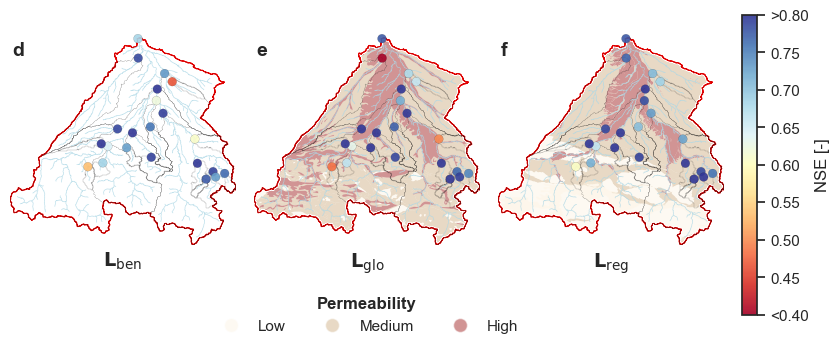

In [459]:
network_estreams_gdf = network_estreams_garonne_22_gauges.loc[~network_estreams_garonne_22_gauges.index.duplicated(keep='first')]

catchment_boundaries_garonne = catchment_boundaries.loc[network_estreams_gdf.index.tolist(), :]

#selected_ids = ["DERP2013", "FR000144", "FR000183", "FR000185", "FR003250", "FR003259","FR003280"]


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines


# Create a GeoDataFrame from network_estreams_filtered
geometry = [Point(xy) for xy in zip(network_estreams_gdf['lon'], network_estreams_gdf['lat'])]
network_estreams_gdf = gpd.GeoDataFrame(network_estreams_gdf, geometry=geometry, crs='EPSG:4326')
network_estreams_gdf["basin_id"] = network_estreams_gdf.index

# Define the first color mapping for GLiM_dissolved
color_mapping_glim = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology = {
    'very low': "oldlace",  
    'low': "tan",  
    'medium': "tan",  
    'high': "brown"
}

# Define the second color mapping for geology_median_dissolved
color_mapping_geology2 = {
    'very low': "oldlace",  
    'low': "oldlace",  
    'medium': "tan",  
    'high': "brown"
}

color_dict_legend = {
    'very low': 'oldlace',
    'low': 'tan',
    'medium': 'tan',
    'high': 'brown'
}

# Add a column for colors based on the class
GLiM_garonne_dissolved['color'] = GLiM_garonne_dissolved['permeability'].map(color_mapping_glim)
geology_median_garonne_dissolved['color'] = geology_median_garonne_dissolved['permeability'].map(color_mapping_geology)
geology_high_garonne_dissolved['color'] = geology_high_garonne_dissolved['permeability'].map(color_mapping_geology2)

# Set style
sns.set_theme(style="ticks")

# Copy and add coordinates
df = data_diff_val_complete_dict_plot_garonne.copy()
df[["lat", "lon"]] = network_estreams_garonne_22_gauges[["lat", "lon"]]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(7.5, 5), sharex=True, sharey=True)

# NSE columns and titles
nse_cols = ['nse_nogeo', 'nse_g1comp', 'nse_r1comp']
titles = ['d', 'e', 'f']
main_titles = [r"$\mathbf{L_{\mathrm{ben}}}$", r"$\mathbf{L_{\mathrm{glo}}}$", 
                r"$\mathbf{L_{\mathrm{reg}}}$"]

background_maps = ['none', 'GLiM','high']

# Set plot limits to the bounding box of the selected study areas
FR_selected_gdf = garonne.copy()
bounds = FR_selected_gdf.total_bounds
x_min, y_min, x_max, y_max = bounds[0], bounds[1], bounds[2], bounds[3]+ 0.02

## Create a mask that covers the entire plotting area
plot_extent = box(x_min - 1, y_min - 1, x_max + 1, y_max + 1)
#mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')
mask = gpd.GeoDataFrame({'geometry': [plot_extent]}, crs='EPSG:4326')

# Combine the selected geometries into one
combined_geometry = FR_selected_gdf.unary_union

# Create the mask by subtracting the combined geometry from the plot extent
mask['geometry'] = mask.difference(combined_geometry)


# Color setup
vmin, vmax = 0.4, 0.8
cmap_nse = plt.cm.RdYlBu

# Plot loop
for ax, col, subtitle, maintitle, bg_type in zip(axes, nse_cols, titles, main_titles, background_maps):

    # Add background geology map where appropriate
    if bg_type == 'GLiM':
        GLiM_garonne_dissolved.plot(column='permeability', ax=ax, color=GLiM_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'median':
        geology_median_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_median_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)
    elif bg_type == 'high':
        geology_high_garonne_dissolved.plot(column='permeability', ax=ax, color=geology_high_garonne_dissolved['color'], edgecolor='none', linewidth=0, alpha=0.5)

    # Add rivers and boundary for all
    garonne.plot(ax=ax, color='none', linewidth=2, alpha=1)
    rivers_garonne.plot(ax=ax, color='lightblue', linewidth=0.5, alpha=0.75)

#   if bg_type != 'none':
    FR_selected_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.25)
    mask.plot(ax=ax, facecolor='white', edgecolor='red', linewidth=0.75)

    # Scatter NSE values
    sc = ax.scatter(
        df['lon'], df['lat'],
        c=df[col],
        cmap=cmap_nse,
        vmin=vmin,
        vmax=vmax,
        s=40,
        edgecolor='k',
        linewidth=0.1,
        alpha=0.9,
        zorder=10
    )

    # Subplot letter
    ax.text(0.01, 0.97, subtitle, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

    # Set plot limits to the bounding box of the study area
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Clean look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(maintitle, fontsize=14, fontweight='bold')
    ax.set_ylabel("")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


    catchment_boundaries_garonne.plot(ax=ax, facecolor='none', edgecolor='k', linewidth=0.1, label='Sub-catchments')



# Colorbar setup
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('NSE [-]')
ticks = np.linspace(0.4, 0.8, num=9
                    )
tick_labels = [f"<0.40"] + [f"{t:.2f}" for t in ticks[1:-1]] + [f">0.80"]
#cbar.set_ticks(ticks)
cbar.set_ticks(np.arange(vmin, vmax + 0.05, 0.05))

cbar.set_ticklabels(tick_labels)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Define the color dictionary with alpha transparency (0.5 for 50% opacity)
color_dict_legend = {
    'Low': to_rgba('oldlace', 0.5),
    'Medium': to_rgba('tan', 0.5),
    'High': to_rgba('brown', 0.5)
}

# Create custom legend elements with alpha applied to markerfacecolor
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label, linewidth=0.5)
                   for label, color in color_dict_legend.items()]

# Add the legend outside the plot area with minimal space
legend = fig.legend(handles=legend_elements, title='Permeability', loc='center', frameon=False, 
                   bbox_to_anchor=(0.5, 0.15), ncol=5)
# Make the legend title bold
legend.get_title().set_fontweight('bold')


#axes[0].text(7.419000,49.27, "DERP2013", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.014472,48.7, "FR00185", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.18,48.5, "FR00183", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.2,48.38, "FR00144", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(7.35,48.15, "FR03250", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(6.645964,48.21, "FR03259", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
#axes[0].text(5.9,49.28, "FR03280", fontsize=8, ha='center', va='bottom', zorder=20, color='black')
	
# Save and show
plt.tight_layout()

# Save including everything (colorbar + legend)
plt.savefig(
    "../results/figs/figures/fig_3geomapsb_lstm.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# End